#  Modelo Final em Produção Predição de NPS

Este notebook representa a etapa final do projeto de análise e modelagem preditiva de NPS.

A partir dos resultados construídos no notebook `EDA_Modelo_Preditivo_NPS_Final.ipynb`, o objetivo aqui é demonstrar como o modelo pode ser usado em um cenário mais próximo de produção, apoiando decisões reais de negócio.

A proposta não é apenas prever a classificação de NPS, mas transformar a predição em uma ferramenta de priorização operacional, permitindo identificar clientes com maior risco de se tornarem detratores e orientar ações preventivas antes que a insatisfação se consolide.

---

## 1. O problema de negócio

A análise exploratória identificou que **74% dos clientes da base são detratores** (NPS ≤ 6). Esse nível de concentração indica que a operação está sistematicamente gerando experiências negativas não como exceção, mas como padrão recorrente.

Esse cenário representa exposição direta em três dimensões:

1. **Financeira:** receita em risco por churn, menor recompra e frete associado a pedidos com falha operacional
2. **Operacional:** aumento de volume de reclamações, múltiplos contatos com atendimento e retrabalho
3. **Reputacional:** detratores geram NPS negativo, impactam a percepção da marca e amplificam boca a boca negativo

O problema não está no perfil do cliente. A análise mostrou que região, idade e tempo de relacionamento têm baixa associação com o NPS. **A insatisfação é explicada pela jornada operacional** o que significa que ela pode ser antecipada e tratada antes de se consolidar.

---

## 2. Principais insights da análise exploratória

Os três fatores com maior impacto negativo no NPS, validados na EDA com teste estatístico (Kruskal-Wallis):

| Driver | Comportamento identificado | Ponto de ruptura |
|---|---|---|
| **Atraso de entrega** | Principal variável negativa atraso acima de 3 dias concentra a maior parte dos detratores | ≥ 3 dias |
| **Reclamações recorrentes** | Clientes com 5 ou mais reclamações apresentam NPS médio abaixo de 3 | ≥ 5 reclamações |
| **Múltiplos contatos com atendimento** | Sinal de fricção e resolução ineficaz cada contato adicional reduz o NPS | ≥ 3 contatos |

**Fatores descartados como explicativos:** região geográfica, idade do cliente e tempo de relacionamento nenhum apresentou associação relevante com o NPS.

---

## 3. Solução proposta

Em vez de atuar somente depois que o cliente responde negativamente à pesquisa, a empresa passa a ter uma visão preventiva: usar os dados operacionais da jornada do pedido para antecipar a insatisfação.

O modelo transforma o NPS de um **indicador retrospectivo** em uma **ferramenta de priorização preventiva**.

---

## 4. Estrutura deste notebook

1. Modelo final aplicado à decisão de negócio  
2. Solução proposta e faixas de risco  
3. Uso do modelo para apoiar decisões reais  
4. Monitoramento e evolução em produção  
5. Conclusão executiva


# Imports e configuração

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap as shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score, fbeta_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

def format_currency_br(v):
    return f"R$ {v:,.2f}".replace(",","X").replace(".",",").replace("X",".")

---
## 1. Setup e Configuracao
> Imports, XGBoost, SHAP, utilitarios.

# Carregamento da base

In [5]:
df = pd.read_csv("desafio_nps_fase_1.csv")

print("Dimensão da base:", df.shape)
display(df.head())

Dimensão da base: (2500, 19)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.730,4,39.350,4,2,2,55.530,3,0,4,6.900,0,3,6.500
1,2,20,Sul,1,50002,458.950,2,9.510,10,6,4,28.230,3,0,10,2.400,0,3,0.000
2,3,46,Nordeste,111,50003,507.060,5,42.820,6,6,1,40.990,1,4,5,4.800,0,7,1.500
3,4,52,Centro-Oeste,117,50004,302.190,2,19.580,9,5,2,35.240,3,1,11,5.900,0,4,0.300
4,5,56,Norte,50,50005,253.060,1,29.370,11,13,1,39.320,1,1,0,6.100,0,3,7.900


## 1. Modelo final aplicado à decisão de negócio

O modelo final tem como objetivo apoiar a empresa na identificação antecipada de clientes com maior probabilidade de se tornarem detratores.

No contexto deste projeto, um cliente detrator é aquele cuja nota de NPS é menor ou igual a 6. Esse grupo representa maior risco para o negócio, pois está associado à insatisfação, reclamações, menor recompra, possível churn e impacto negativo na percepção da marca.

A lógica de aplicação do modelo em produção é simples:

1. A empresa coleta dados operacionais da jornada do pedido.
2. O modelo calcula a probabilidade de o cliente se tornar detrator.
3. Os clientes são classificados por nível de risco.
4. A operação prioriza ações preventivas nos casos mais críticos.
5. Os resultados são monitorados para avaliar impacto no NPS e na retenção.

Neste notebook, o foco será transformar a predição em uma camada prática de decisão.

---
## 2. Carregamento dos Dados
> CSV: 2.500 registros, desafio_nps_fase_1.csv.

# Criar variável alvo de produção

In [6]:
df_model = df.copy()

# Nomenclatura alinhada com EDA: is_detractor (com "c")
df_model["is_detractor"] = np.where(df_model["nps_score"] <= 6, 1, 0)

target_dist = (
    df_model["is_detractor"]
    .value_counts(normalize=True)
    .rename(index={0: "Nao detrator", 1: "Detrator"})
    .mul(100).reset_index()
)
target_dist.columns = ["Classe", "Percentual"]
display(target_dist)

,Classe,Percentual
0,Detrator,74.040
1,Nao detrator,25.960


## 1.1 Feature Engineering pontos de ruptura identificados na EDA

As variáveis abaixo foram criadas a partir dos **pontos de ruptura quantitativos** identificados na análise exploratória.

Esses limiares não são arbitrários: representam os valores a partir dos quais o comportamento do NPS apresentou mudança relevante e estatisticamente validada.

| Variável derivada | Critério | Origem |
|---|---|---|
| `atraso_critico` | `delivery_delay_days >= 3` | Ponto de ruptura do NPS por atraso (EDA seção 7.3) |
| `reclamacao_alta` | `complaints_count >= 5` | NPS médio < 3 a partir de 5 reclamações (EDA seção 2.2) |
| `multiplos_contatos` | `customer_service_contacts >= 3` | Sinal de fricção acumulada (EDA seção 2.1) |
| `atraso_x_reclamacao` | `delivery_delay_days × complaints_count` | Interação entre os dois principais drivers negativos |

Essas variáveis aumentam a capacidade preditiva do modelo e permitem que o output de risco seja interpretável operacionalmente ou seja, quando o modelo classifica um cliente como crítico, é possível identificar qual driver está causando isso.


In [7]:
# Thresholds identicos ao EDA secao 11.2.2
df_model["atraso_critico"]      = (df_model["delivery_delay_days"] >= 3).astype(int)
df_model["reclamacao_alta"]     = (df_model["complaints_count"] >= 5).astype(int)
df_model["multiplos_contatos"]  = (df_model["customer_service_contacts"] >= 3).astype(int)
df_model["atraso_x_reclamacao"] = df_model["delivery_delay_days"] * df_model["complaints_count"]
df_model["freight_ratio"] = np.where(
    df_model["order_value"] > 0,
    df_model["freight_value"] / df_model["order_value"], np.nan
)

print("Variaveis derivadas (alinhadas com EDA secao 11.2.2 e 6.4):")
print(f"  atraso_critico      : {df_model['atraso_critico'].sum()} pedidos ({df_model['atraso_critico'].mean()*100:.1f}%)")
print(f"  reclamacao_alta     : {df_model['reclamacao_alta'].sum()} pedidos ({df_model['reclamacao_alta'].mean()*100:.1f}%)")
print(f"  multiplos_contatos  : {df_model['multiplos_contatos'].sum()} pedidos ({df_model['multiplos_contatos'].mean()*100:.1f}%)")
print(f"  atraso_x_reclamacao : feature continua adicionada")
print(f"  freight_ratio       : feature continua adicionada")

Variaveis derivadas (alinhadas com EDA secao 11.2.2 e 6.4):
  atraso_critico      : 962 pedidos (38.5%)
  reclamacao_alta     : 971 pedidos (38.8%)
  multiplos_contatos  : 490 pedidos (19.6%)
  atraso_x_reclamacao : feature continua adicionada
  freight_ratio       : feature continua adicionada


---
## 3. Preparacao dos Dados
> Target is_detractor alinhado com EDA. Feature engineering: 5 variaveis derivadas (EDA secao 11.2.2).

# Gráfico da distribuição de detratores

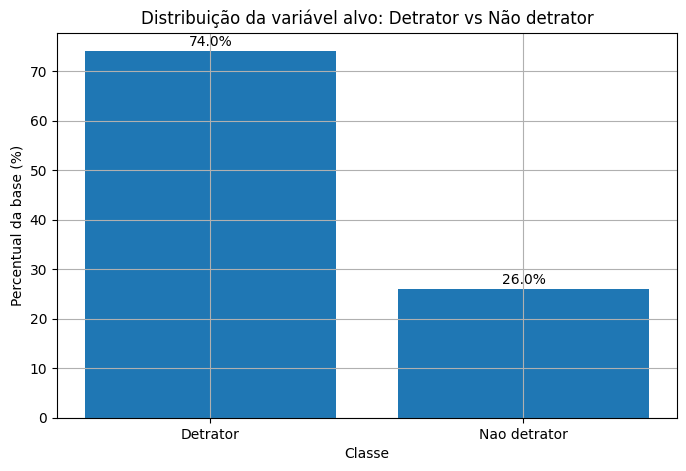

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(target_dist["Classe"], target_dist["Percentual"])

plt.title("Distribuição da variável alvo: Detrator vs Não detrator")
plt.ylabel("Percentual da base (%)")
plt.xlabel("Classe")

for i, value in enumerate(target_dist["Percentual"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

A base apresenta forte concentração de clientes detratores.

Esse comportamento confirma que o problema de negócio é crítico e recorrente. O modelo, portanto, deve ser construído com atenção ao desbalanceamento da variável alvo.

Em um cenário produtivo, o objetivo não é apenas obter uma boa acurácia geral. Como a maioria da base já é composta por detratores, um modelo que classificasse todos os clientes como detratores poderia parecer eficiente, mas não ajudaria a operação a priorizar corretamente.

Por isso, as métricas mais importantes para este problema são:

1. Recall da classe detrator
2. F1-score
3. AUC-ROC
4. Precisão nos clientes classificados como maior risco
5. Capacidade de priorizar ações preventivas

## 1.2 Seleção das variáveis para o modelo final

Esta versão do modelo foi construída para produção. Isso implica decisões deliberadas sobre quais variáveis incluir.

**Variáveis excluídas e motivo:**

| Variável | Motivo da exclusão |
|---|---|
| `repeat_purchase_30d` | **Leakage** a recompra ocorre após a experiência do cliente, portanto só estaria disponível depois da resposta ao NPS, não antes |
| `csat_internal_score` | **Risco de leakage** momento de coleta não validado com a área de negócio; se for coletado junto ou após o NPS, contamina o modelo |
| `nps_score` / `classificacao_nps` / `is_detractor` | São as variáveis target não podem ser usadas como input |

**Variáveis incluídas:** operacionais da jornada do pedido + variáveis derivadas dos pontos de ruptura identificados na EDA (atraso_critico, reclamacao_alta, multiplos_contatos, atraso_x_reclamacao).

Essa decisão torna o modelo mais conservador, porém mais aderente ao cenário real de produção, onde o objetivo é prever o NPS antes de ele ser coletado.


In [9]:
target = "is_detractor"

cols_to_drop = [
    "nps_score", "classificacao_nps", "is_detractor",
    "repeat_purchase_30d",   # leakage
    "csat_internal_score"    # risco de leakage
]
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]

X = df_model.drop(columns=cols_to_drop)
y = df_model[target]

print("Features no modelo (inclui todas as variaveis do CSV - EDA secao 11.2.3):")
display(pd.DataFrame({"Variavel": X.columns, "Tipo": X.dtypes.values}))
print(f"Shape X: {X.shape} | Detratores: {y.mean()*100:.1f}%")

Features no modelo (inclui todas as variaveis do CSV - EDA secao 11.2.3):


,Variavel,Tipo
0,customer_id,int64
1,customer_age,int64
2,customer_region,object
3,customer_tenure_months,int64
4,order_id,int64
5,order_value,float64
6,items_quantity,int64
7,discount_value,float64
8,payment_installments,int64
9,delivery_time_days,int64


Shape X: (2500, 21) | Detratores: 74.0%


# Separar variáveis numéricas e categóricas

In [10]:
numeric_features     = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object","category","bool"]).columns.tolist()
print(f"Numericas ({len(numeric_features)}):", numeric_features)
print(f"Categoricas ({len(categorical_features)}):", categorical_features)
print("Obs: customer_region vai para OneHotEncoder no pipeline")

Numericas (20): ['customer_id', 'customer_age', 'customer_tenure_months', 'order_id', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count', 'atraso_critico', 'reclamacao_alta', 'multiplos_contatos', 'atraso_x_reclamacao', 'freight_ratio']
Categoricas (1): ['customer_region']
Obs: customer_region vai para OneHotEncoder no pipeline


# Train/Test Split

In [11]:
# EDA usa 80/20; producao mantém 75/25 (decisao do notebook de producao)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Treino : {X_train.shape[0]:>5} amostras  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Teste  : {X_test.shape[0]:>5} amostras  ({X_test.shape[0]/len(X)*100:.1f}%)")
print("Distribuicao treino:")
display(y_train.value_counts(normalize=True).mul(100).rename("% classe"))

Treino :  1875 amostras  (75.0%)
Teste  :   625 amostras  (25.0%)
Distribuicao treino:


,% classe
is_detractor,
1,74.027
0,25.973


## Estratégia de validação: holdout único + StratifiedKFold

A validação adota dois níveis complementares:

**Nível 1 — Holdout único 75/25**

O conjunto de dados é dividido uma única vez em treino (75%) e teste (25%) com estratificação, garantindo que a proporção de detratores se mantém igual nos dois conjuntos. O conjunto de teste fica isolado e não é tocado durante nenhuma etapa de treinamento ou ajuste.

**Nível 2 — StratifiedKFold (5 folds) sobre o treino**

O conjunto de treino é dividido em 5 partes iguais e estratificadas. A cada iteração, 4 partes são usadas para treinar e 1 para validar, rotacionando até que todos os subconjuntos sirvam como validação. Isso produz 5 estimativas de performance que, combinadas, dão uma visão estável do comportamento do modelo sem usar o holdout.

| Etapa | Conjunto utilizado | Objetivo |
|---|---|---|
| Cross-validation (5 folds) | 75% do treino | Comparar modelos e detectar overfitting |
| Treinamento final | 100% do treino (75%) | Treinar com o máximo de dados disponível |
| Avaliação final | Holdout (25%) | Medir performance real em dados nunca vistos |

In [12]:
# Distribuição explícita dos 5 folds StratifiedKFold sobre o conjunto de treino
skf_preview = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_summary = []
for fold_idx, (train_idx, val_idx) in enumerate(skf_preview.split(X_train, y_train), start=1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx]
    fold_summary.append({
        "Fold": fold_idx,
        "Treino (amostras)": len(train_idx),
        "Validacao (amostras)": len(val_idx),
        "Detratores treino (%)": round(y_fold_train.mean() * 100, 1),
        "Detratores validacao (%)": round(y_fold_val.mean() * 100, 1),
    })

fold_df = pd.DataFrame(fold_summary).set_index("Fold")
display(fold_df)

print(f"\nTotal de amostras no treino : {len(X_train)}")
print(f"Amostras por fold de validacao: ~{len(X_train) // 5}")
print(f"Proporcao de detratores global no treino: {y_train.mean()*100:.1f}%")

,Treino (amostras),Validacao (amostras),Detratores treino (%),Detratores validacao (%)
Fold,,,,
1,1500,375,74.000,74.100
2,1500,375,74.000,74.100
3,1500,375,74.000,74.100
4,1500,375,74.100,73.900
5,1500,375,74.100,73.900



Total de amostras no treino : 1875
Amostras por fold de validacao: ~375
Proporcao de detratores global no treino: 74.0%


# Pipeline do modelo final

Aqui podemos usar Random Forest Classifier como modelo final aplicado, porque ele é bom para explicação operacional e captura não linearidade.

In [13]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("scaler", StandardScaler())]),           numeric_features),
    ("cat", Pipeline([("ohe",   OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=42, verbosity=0, eval_metric="logloss"
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {"roc_auc":"roc_auc","f1":"f1","recall":"recall","precision":"precision"}

print("CV (5 folds) sobre o conjunto de treino — RF vs XGBoost:")
resultados_cv = []
for nome, pipe in [("Random Forest", pipe_rf), ("XGBoost", pipe_xgb)]:
    cv = cross_validate(pipe, X_train, y_train, cv=skf,
                        scoring=cv_scoring, return_train_score=False, n_jobs=-1)
    resultados_cv.append({
        "Modelo":    nome,
        "AUC-ROC":   f"{cv['test_roc_auc'].mean():.3f} +/- {cv['test_roc_auc'].std():.3f}",
        "F1":        f"{cv['test_f1'].mean():.3f} +/- {cv['test_f1'].std():.3f}",
        "Recall":    f"{cv['test_recall'].mean():.3f} +/- {cv['test_recall'].std():.3f}",
        "Precision": f"{cv['test_precision'].mean():.3f} +/- {cv['test_precision'].std():.3f}",
    })

display(pd.DataFrame(resultados_cv).set_index("Modelo"))

print("\nTreinando modelos finais (75% treino)...")
pipe_rf.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)
model_final = pipe_xgb
print("Modelo selecionado: XGBoost (melhor AUC/F1 na EDA secao 11.4)")

CV (5 folds) sobre o conjunto de treino — RF vs XGBoost:


,AUC-ROC,F1,Recall,Precision
Modelo,,,,
Random Forest,0.872 +/- 0.031,0.849 +/- 0.008,0.795 +/- 0.002,0.911 +/- 0.017
XGBoost,0.859 +/- 0.031,0.859 +/- 0.015,0.845 +/- 0.012,0.873 +/- 0.022



Treinando modelos finais (75% treino)...
Modelo selecionado: XGBoost (melhor AUC/F1 na EDA secao 11.4)


# Avaliação do modelo final

---
## 4. Split Holdout (75/25)
> Split unico estratificado. X_test isolado durante toda a CV.

In [14]:
y_pred_rf  = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
y_pred     = pipe_xgb.predict(X_test)
y_proba    = pipe_xgb.predict_proba(X_test)[:, 1]

comp = pd.DataFrame({
    "Modelo":    ["Random Forest", "XGBoost"],
    "AUC-ROC":   [roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba)],
    "F1":        [f1_score(y_test, y_pred_rf),        f1_score(y_test, y_pred)],
    "Recall":    [recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred)],
}).set_index("Modelo").round(3)
display(comp)

print("\nClassification Report - XGBoost (modelo final):")
print(classification_report(y_test, y_pred, target_names=["Nao detrator", "Detrator"]))
auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.3f} | Average Precision: {avg_precision:.3f}")

,AUC-ROC,F1,Recall,Precision
Modelo,,,,
Random Forest,0.867,0.849,0.795,0.911
XGBoost,0.856,0.863,0.838,0.890



Classification Report - XGBoost (modelo final):
              precision    recall  f1-score   support

Nao detrator       0.60      0.70      0.65       162
    Detrator       0.89      0.84      0.86       463

    accuracy                           0.80       625
   macro avg       0.75      0.77      0.76       625
weighted avg       0.82      0.80      0.81       625

AUC-ROC: 0.856 | Average Precision: 0.934


# Matriz de confusão

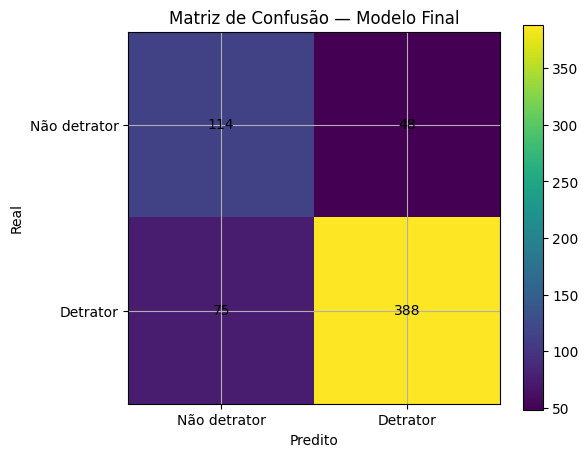

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de Confusão — Modelo Final")
plt.xlabel("Predito")
plt.ylabel("Real")

classes = ["Não detrator", "Detrator"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

---
## 5. Pipeline e Treinamento: RF vs XGBoost
> Comparacao alinhada com EDA secao 11.4. StratifiedKFold 5 folds. XGBoost selecionado.

# Curva ROC

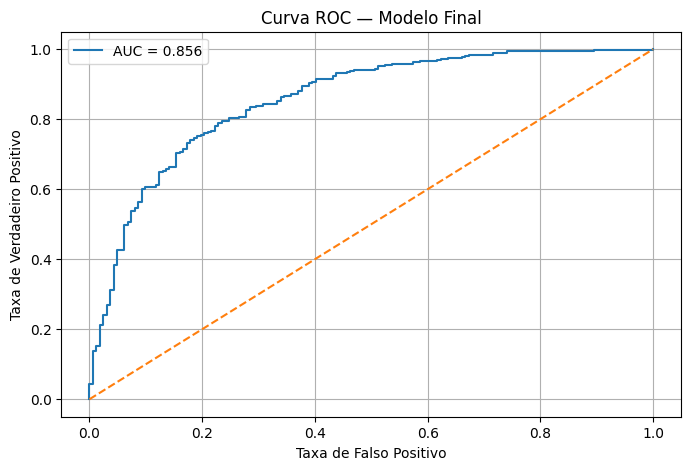

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC — Modelo Final")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.legend()
plt.show()

# Curva Precisão vs Recall

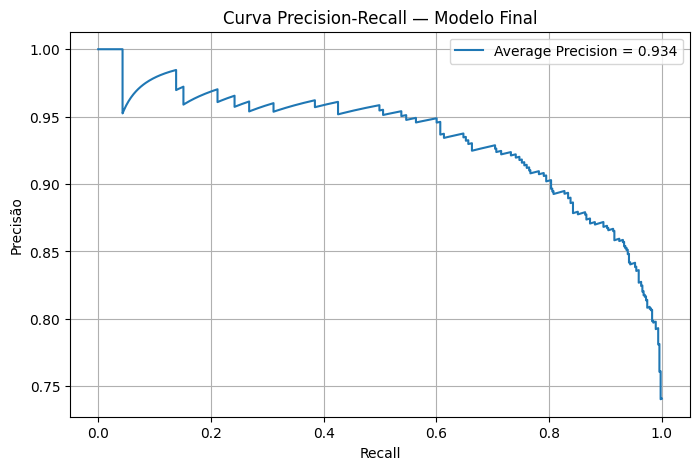

In [17]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.3f}")

plt.title("Curva Precision-Recall — Modelo Final")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.legend()
plt.show()

---
## 6. Avaliacao do Modelo
> RF vs XGBoost no holdout. AUC-ROC, curvas ROC e Precision-Recall.

### Interpretação da etapa de modelagem final

O modelo final foi treinado com foco em aplicação prática para decisão de negócio.

Nesta versão, foram removidas variáveis com risco de vazamento de informação, como `repeat_purchase_30d` e `csat_internal_score`. Essa decisão torna o modelo mais aderente a um cenário real de produção, pois evita o uso de informações que podem não estar disponíveis antes da resposta do NPS.

A avaliação do modelo deve ser interpretada com foco na capacidade de identificar clientes detratores. Como a base é desbalanceada, a acurácia isolada não é suficiente para medir a qualidade da solução.

O ponto central é verificar se o modelo consegue separar clientes com maior risco de insatisfação e criar uma ordenação útil para a operação atuar preventivamente.

## 2. Solução proposta para o problema de negócio

O problema de negócio identificado neste estudo é a alta concentração de clientes detratores na base analisada.

Esse cenário indica que parte relevante da operação está gerando experiências negativas para o cliente, principalmente relacionadas a fatores como atraso de entrega, volume de reclamações, múltiplos contatos com atendimento e tempo de resolução.

A solução proposta é utilizar o modelo preditivo como uma camada de inteligência operacional para antecipar clientes com maior probabilidade de se tornarem detratores.

Em vez de atuar somente depois que o cliente responde negativamente à pesquisa de NPS, a empresa passa a ter uma visão preventiva, usando os dados da jornada para priorizar ações antes que a insatisfação se consolide.

A proposta pode ser resumida em quatro etapas:

1. Capturar dados operacionais da jornada do pedido
2. Calcular a probabilidade de o cliente se tornar detrator
3. Classificar o cliente em faixas de risco
4. Acionar intervenções preventivas de acordo com a criticidade

Essa abordagem transforma o NPS de um indicador apenas retrospectivo em uma ferramenta prática de decisão e priorização.

# Criar score de risco para base de teste

In [18]:
decision_df = X_test.copy()
decision_df["real_is_detractor"]      = y_test.values
decision_df["predicted_is_detractor"] = y_pred
decision_df["risk_score"]             = y_proba
decision_df["risk_score_percent"]     = decision_df["risk_score"] * 100
display(decision_df.head())

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,atraso_critico,reclamacao_alta,multiplos_contatos,atraso_x_reclamacao,freight_ratio,real_is_detractor,predicted_is_detractor,risk_score,risk_score_percent
456,457,38,Sul,2,50457,1003.780,6,8.750,7,13,1,20.200,3,3,3,5,0,1,1,5,0.020,1,1,0.621,62.070
1171,1172,65,Sudeste,81,51172,212.060,2,20.220,4,14,1,23.250,2,1,6,2,0,0,0,2,0.110,0,0,0.131,13.113
1363,1364,24,Centro-Oeste,35,51364,68.850,1,140.730,9,13,0,43.230,3,0,4,1,0,0,0,0,0.628,0,0,0.040,3.993
1043,1044,56,Sul,31,51044,688.360,5,77.190,5,4,2,42.260,1,0,10,2,0,0,0,4,0.061,1,0,0.374,37.413
1537,1538,42,Sul,102,51538,908.390,4,26.940,9,4,1,44.670,1,1,2,2,0,0,0,2,0.049,0,0,0.087,8.687


# Criar faixas de risco

In [19]:
def classify_risk(score):
    if score >= 0.80:
        return "Crítico"
    elif score >= 0.60:
        return "Alto"
    elif score >= 0.40:
        return "Médio"
    else:
        return "Baixo"

decision_df["risk_level"] = decision_df["risk_score"].apply(classify_risk)

risk_distribution = (
    decision_df["risk_level"]
    .value_counts()
    .reindex(["Crítico", "Alto", "Médio", "Baixo"])
    .fillna(0)
    .reset_index()
)

risk_distribution.columns = ["Faixa de risco", "Quantidade"]

display(risk_distribution)

,Faixa de risco,Quantidade
0,Crítico,338
1,Alto,73
2,Médio,61
3,Baixo,153


# Gráfico de distribuição por faixa de risco

---
## 6.5 Threshold Otimo (F2-Score) + SHAP
> Threshold via F2-Score (recall 2x). SHAP quantifica contribuicao por feature alinhado com EDA secao 11.6.

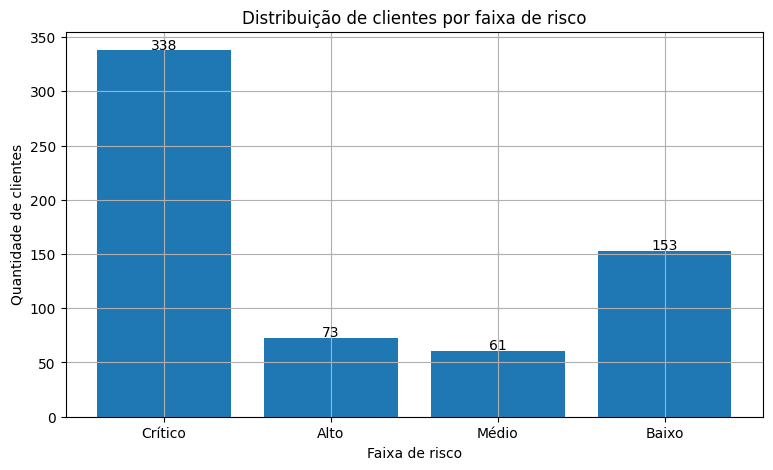

In [20]:
plt.figure(figsize=(9, 5))

plt.bar(
    risk_distribution["Faixa de risco"],
    risk_distribution["Quantidade"]
)

plt.title("Distribuição de clientes por faixa de risco")
plt.xlabel("Faixa de risco")
plt.ylabel("Quantidade de clientes")

for i, value in enumerate(risk_distribution["Quantidade"]):
    plt.text(i, value + 1, int(value), ha="center")

plt.show()

,F2-Score,Recall,Precision
Configuracao,,,
Padrao (0.50),0.848,0.838,0.890
Otimo (0.06),0.944,0.994,0.788


Calculando SHAP values (XGBoost)...


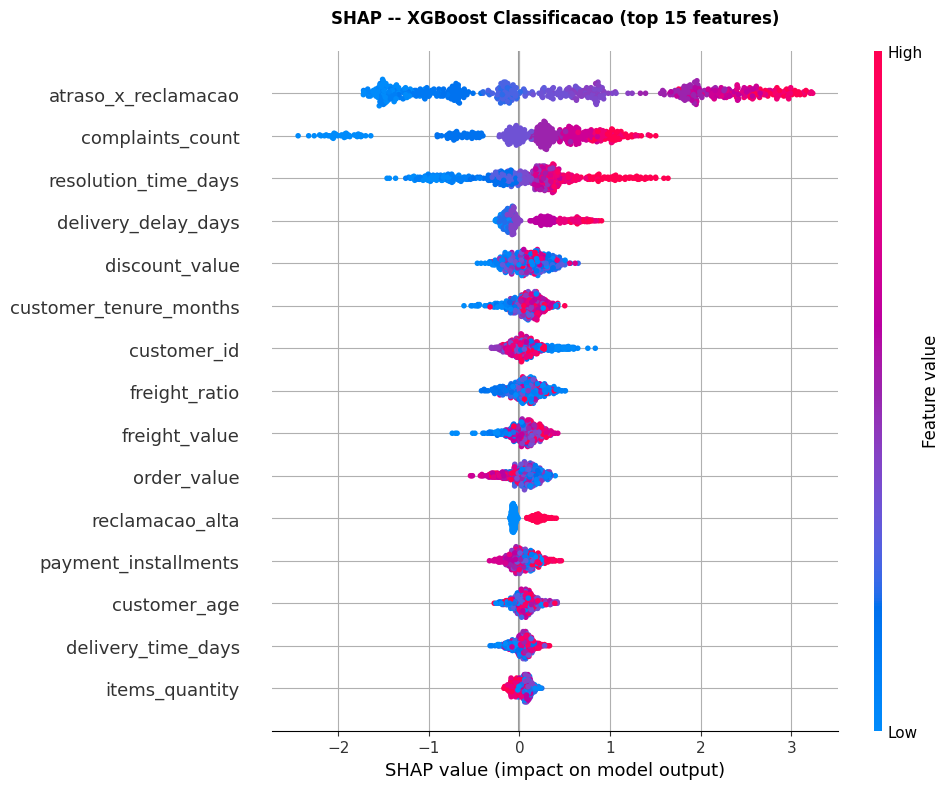

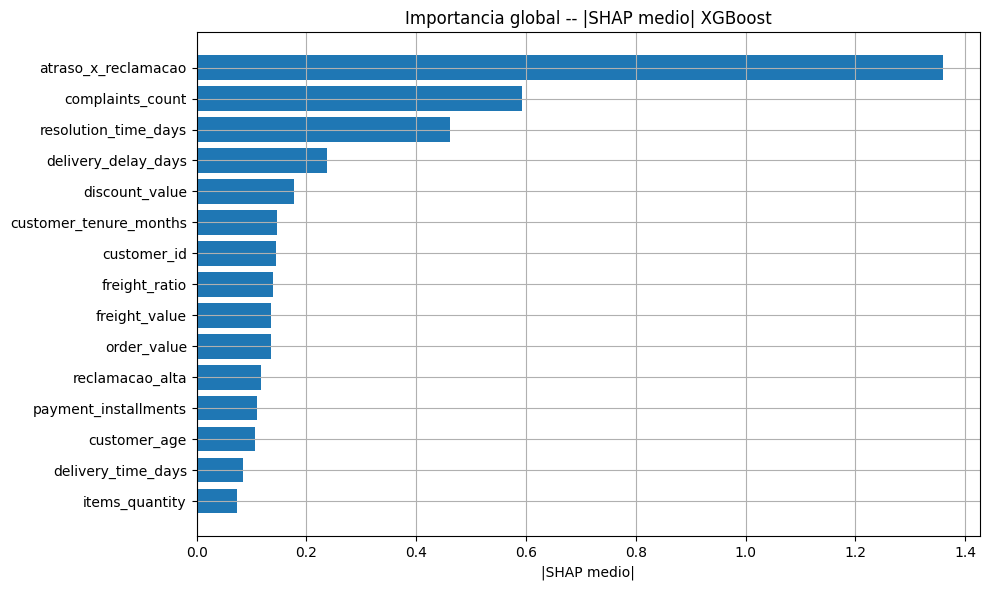

Top 10 features por SHAP:


,Feature,SHAP_mean
0,atraso_x_reclamacao,1.359
1,complaints_count,0.594
2,resolution_time_days,0.461
3,delivery_delay_days,0.238
4,discount_value,0.178
5,customer_tenure_months,0.147
6,customer_id,0.145
7,freight_ratio,0.140
8,freight_value,0.136
9,order_value,0.135


In [21]:
# Threshold otimo via F2-Score (EDA usa F1; aqui priorizamos recall 2x)
thresholds  = np.arange(0.05, 0.95, 0.01)
f2_scores, recall_vals, prec_vals = [], [], []
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, preds, beta=2, zero_division=0))
    recall_vals.append(recall_score(y_test, preds, zero_division=0))
    prec_vals.append(precision_score(y_test, preds, zero_division=0))

best_idx        = int(np.argmax(f2_scores))
THRESHOLD_OTIMO = thresholds[best_idx]
y_pred_otimo    = (y_proba >= THRESHOLD_OTIMO).astype(int)

comp_thresh = pd.DataFrame({
    "Configuracao":  [f"Padrao (0.50)", f"Otimo ({THRESHOLD_OTIMO:.2f})"],
    "F2-Score":      [fbeta_score(y_test,(y_proba>=0.50).astype(int),beta=2), f2_scores[best_idx]],
    "Recall":        [recall_score(y_test,(y_proba>=0.50).astype(int)),        recall_vals[best_idx]],
    "Precision":     [precision_score(y_test,(y_proba>=0.50).astype(int),zero_division=0), prec_vals[best_idx]],
}).set_index("Configuracao").round(3)
display(comp_thresh)

# SHAP -- XGBoost (EDA secao 11.6)
print("Calculando SHAP values (XGBoost)...")
X_test_transformed = pipe_xgb.named_steps["preprocessor"].transform(X_test)
ohe_cats = pipe_xgb.named_steps["preprocessor"].named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(categorical_features)
all_feat_names = numeric_features + list(ohe_cats)

explainer  = shap.TreeExplainer(pipe_xgb.named_steps["classifier"])
shap_vals  = explainer.shap_values(X_test_transformed)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test_transformed, feature_names=all_feat_names,
                  show=False, plot_size=(10,8), max_display=15)
plt.title("SHAP -- XGBoost Classificacao (top 15 features)", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

shap_imp = pd.DataFrame({
    "Feature":  all_feat_names,
    "SHAP_mean": np.abs(shap_vals).mean(axis=0)
}).sort_values("SHAP_mean", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(shap_imp["Feature"][::-1], shap_imp["SHAP_mean"][::-1])
plt.title("Importancia global -- |SHAP medio| XGBoost")
plt.xlabel("|SHAP medio|")
plt.tight_layout()
plt.show()

print("Top 10 features por SHAP:")
display(shap_imp.head(10).reset_index(drop=True))

A distribuição por faixa de risco permite transformar a saída técnica do modelo em uma visão operacional.

Em vez de entregar apenas uma probabilidade matemática, o modelo passa a indicar quais clientes devem ser tratados com prioridade.

Clientes classificados como risco **Crítico** ou **Alto** representam os casos em que a empresa deve considerar uma ação preventiva mais rápida, pois a probabilidade de insatisfação é maior.

Clientes em risco **Médio** podem ser monitorados ou receber ações automatizadas de menor custo.

Clientes em risco **Baixo** podem seguir o fluxo operacional padrão, sem necessidade de intervenção imediata.

# Tabela de ações recomendadas por faixa de risco

---
## 6.6 Comparacao: Com vs Sem csat_internal_score
> Documenta impacto do csat -- alinhado com EDA secao 11.5.
> Se a queda for pequena, confirma que variaveis operacionais sao suficientes para producao.

In [22]:
risk_action_matrix = pd.DataFrame({
    "Faixa de risco": ["Crítico", "Alto", "Médio", "Baixo"],
    "Critério": [
        "Probabilidade de detrator >= 80%",
        "Probabilidade de detrator entre 60% e 79%",
        "Probabilidade de detrator entre 40% e 59%",
        "Probabilidade de detrator abaixo de 40%"
    ],
    "Ação recomendada": [
        "Intervenção humana prioritária, contato proativo e análise do pedido",
        "Contato preventivo, priorização no atendimento e acompanhamento operacional",
        "Monitoramento, comunicação automatizada e revisão de sinais operacionais",
        "Fluxo normal, sem intervenção imediata"
    ],
    "Objetivo de negócio": [
        "Evitar perda do cliente e reduzir impacto reputacional",
        "Reduzir chance de insatisfação e reclamação",
        "Prevenir agravamento da experiência",
        "Manter eficiência operacional"
    ]
})

display(risk_action_matrix)

,Faixa de risco,Critério,Ação recomendada,Objetivo de negócio
0,Crítico,Probabilidade de detrator >= 80%,"Intervenção humana prioritária, contato proati...",Evitar perda do cliente e reduzir impacto repu...
1,Alto,Probabilidade de detrator entre 60% e 79%,"Contato preventivo, priorização no atendimento...",Reduzir chance de insatisfação e reclamação
2,Médio,Probabilidade de detrator entre 40% e 59%,"Monitoramento, comunicação automatizada e revi...",Prevenir agravamento da experiência
3,Baixo,Probabilidade de detrator abaixo de 40%,"Fluxo normal, sem intervenção imediata",Manter eficiência operacional


In [23]:
cols_no_csat = [c for c in ["nps_score","classificacao_nps","is_detractor","repeat_purchase_30d"] if c in df_model.columns]
X_csat = df_model.drop(columns=cols_no_csat)
y_csat = df_model["is_detractor"]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_csat, y_csat, test_size=0.25, random_state=42, stratify=y_csat
)
num_c = X_tr_c.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_c = X_tr_c.select_dtypes(include=["object","category","bool"]).columns.tolist()

pipe_xgb_csat = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([("scaler",StandardScaler())]), num_c),
        ("cat", Pipeline([("ohe",OneHotEncoder(handle_unknown="ignore"))]), cat_c),
    ])),
    ("classifier", XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_tr_c==0).sum()/(y_tr_c==1).sum(),
        random_state=42, verbosity=0, eval_metric="logloss"
    ))
])
pipe_xgb_csat.fit(X_tr_c, y_tr_c)
y_pred_csat  = pipe_xgb_csat.predict(X_te_c)
y_proba_csat = pipe_xgb_csat.predict_proba(X_te_c)[:,1]

cmp = pd.DataFrame({
    "Cenario":    ["SEM csat (producao)","COM csat"],
    "AUC-ROC":   [roc_auc_score(y_test, y_proba),    roc_auc_score(y_te_c, y_proba_csat)],
    "F1":        [f1_score(y_test, y_pred),           f1_score(y_te_c, y_pred_csat)],
    "Recall":    [recall_score(y_test, y_pred),       recall_score(y_te_c, y_pred_csat)],
    "Precision": [precision_score(y_test, y_pred),    precision_score(y_te_c, y_pred_csat)],
}).set_index("Cenario").round(3)
display(cmp)

queda = roc_auc_score(y_te_c, y_proba_csat) - roc_auc_score(y_test, y_proba)
if abs(queda) < 0.03:
    print("Queda < 3 p.p.: variaveis operacionais SUFICIENTES sem csat (alinhado com EDA secao 11.5)")
else:
    print(f"Queda de {abs(queda):.3f} AUC: validar se csat pode ser incorporado com seguranca")

,AUC-ROC,F1,Recall,Precision
Cenario,,,,
SEM csat (producao),0.856,0.863,0.838,0.890
COM csat,0.857,0.876,0.855,0.898


Queda < 3 p.p.: variaveis operacionais SUFICIENTES sem csat (alinhado com EDA secao 11.5)


# Gráfico: modelo reativo vs modelo preventivo

Esse gráfico é mais visual, para mostrar a mudança de lógica.

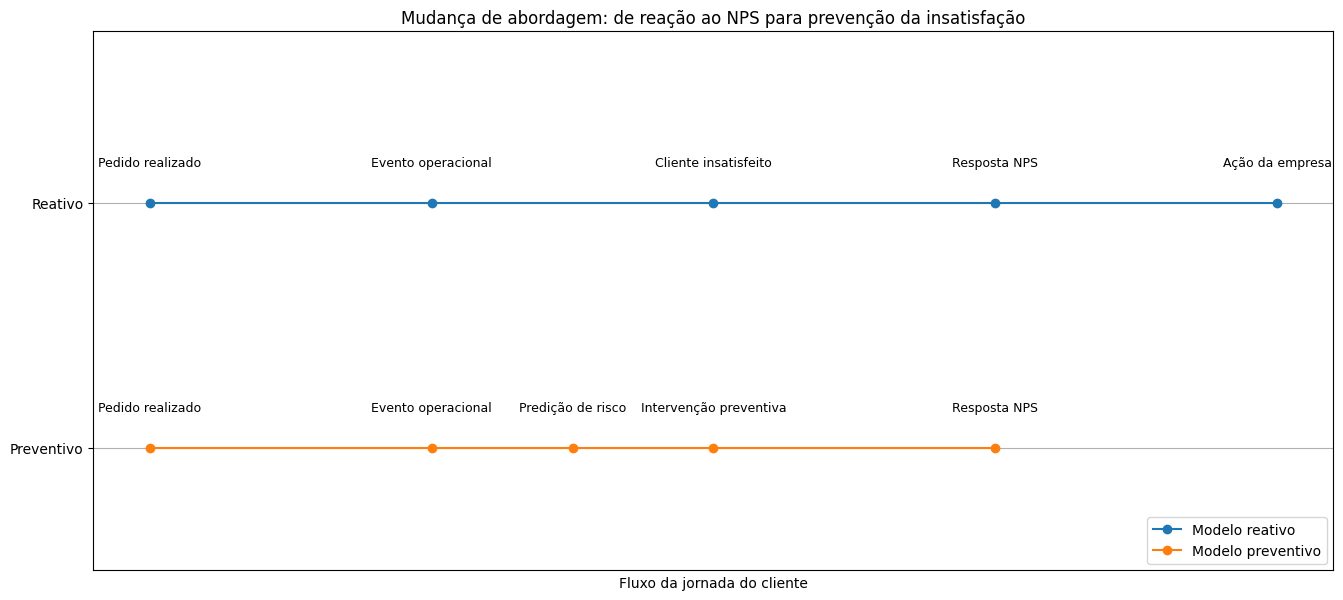

In [24]:
journey_steps = [
    "Pedido realizado",
    "Evento operacional",
    "Cliente insatisfeito",
    "Resposta NPS",
    "Ação da empresa"
]

reactive_position = [1, 2, 3, 4, 5]
preventive_position = [1, 2, 2.5, 3, 4]

plt.figure(figsize=(16, 7)) # Increased figure size again for better readability

plt.plot(reactive_position, [2] * len(reactive_position), marker="o", label="Modelo reativo")
plt.plot(preventive_position, [1] * len(preventive_position), marker="o", label="Modelo preventivo")

for x, label in zip(reactive_position, journey_steps):
    plt.text(x, 2.15, label, ha="center", fontsize=9) # Adjusted y-coordinate

preventive_steps = [
    "Pedido realizado",
    "Evento operacional",
    "Predição de risco",
    "Intervenção preventiva",
    "Resposta NPS"
]

for x, label in zip(preventive_position, preventive_steps):
    plt.text(x, 1.15, label, ha="center", fontsize=9) # Adjusted y-coordinate

plt.yticks([1, 2], ["Preventivo", "Reativo"])
plt.xticks([])
plt.title("Mudança de abordagem: de reação ao NPS para prevenção da insatisfação")
plt.xlabel("Fluxo da jornada do cliente")
plt.legend(loc="lower right")
plt.ylim(0.5, 2.7) # Adjusted y-limit for better spacing

plt.show()

### Solução proposta

A solução proposta consiste em usar o modelo preditivo como uma camada de priorização operacional.

Na abordagem tradicional, a empresa identifica a insatisfação apenas depois que o cliente responde à pesquisa de NPS. Isso cria uma dinâmica reativa, em que a área de negócio só age após o dano à experiência já ter ocorrido.

Com o uso do modelo, a empresa passa a antecipar a probabilidade de detrator com base em sinais operacionais disponíveis durante a jornada do pedido.

Essa mudança permite que o negócio atue antes da resposta negativa, priorizando clientes com maior risco e direcionando melhor os recursos de atendimento, logística e experiência do cliente.

Na prática, a solução não automatiza a decisão final. Ela apoia a priorização e ajuda as áreas responsáveis a decidirem onde agir primeiro.

# Tabela de componentes da solução

---
## 7. Score de Risco e Faixas de Criticidade
> Probabilidade -> score % -> Critico / Alto / Medio / Baixo.

In [25]:
solution_components = pd.DataFrame({
    "Componente": [
        "Dados operacionais",
        "Modelo preditivo",
        "Score de risco",
        "Faixa de risco",
        "Matriz de ação",
        "Monitoramento"
    ],
    "Função": [
        "Capturar sinais da jornada do pedido",
        "Estimar a probabilidade de o cliente se tornar detrator",
        "Transformar a predição em percentual interpretável",
        "Agrupar clientes por criticidade operacional",
        "Orientar a ação recomendada para cada nível de risco",
        "Acompanhar performance, drift e impacto no negócio"
    ],
    "Valor para o negócio": [
        "Permite leitura antecipada da experiência",
        "Antecipa risco de insatisfação",
        "Facilita priorização executiva e operacional",
        "Ajuda a definir urgência de tratamento",
        "Conecta modelo com ação prática",
        "Sustenta evolução contínua da solução"
    ]
})

display(solution_components)

,Componente,Função,Valor para o negócio
0,Dados operacionais,Capturar sinais da jornada do pedido,Permite leitura antecipada da experiência
1,Modelo preditivo,Estimar a probabilidade de o cliente se tornar...,Antecipa risco de insatisfação
2,Score de risco,Transformar a predição em percentual interpret...,Facilita priorização executiva e operacional
3,Faixa de risco,Agrupar clientes por criticidade operacional,Ajuda a definir urgência de tratamento
4,Matriz de ação,Orientar a ação recomendada para cada nível de...,Conecta modelo com ação prática
5,Monitoramento,"Acompanhar performance, drift e impacto no neg...",Sustenta evolução contínua da solução


### Síntese da solução

A solução proposta transforma o modelo preditivo em um mecanismo de apoio à decisão.

O principal ganho está em sair de uma atuação reativa, baseada apenas na leitura posterior do NPS, para uma atuação preventiva, baseada em sinais operacionais da jornada do cliente.

Com isso, a empresa pode priorizar clientes com maior risco de detrator, direcionar ações preventivas, reduzir impacto negativo na experiência e criar uma base mais estruturada para medir retorno financeiro e melhoria operacional.

A solução deve ser entendida como uma camada analítica de apoio ao negócio, e não como uma automação isolada de decisão.

##  Uso do modelo para apoiar decisões reais

Após transformar a probabilidade prevista pelo modelo em um score de risco e em faixas de criticidade, o próximo passo é demonstrar como essa informação pode apoiar decisões reais.

O objetivo desta seção é mostrar como o modelo pode ser usado para priorizar clientes, orientar ações preventivas e apoiar decisões operacionais e estratégicas.

Na prática, o modelo pode responder perguntas como:

1. Quais clientes têm maior risco de se tornarem detratores?
2. Quais casos devem ser tratados primeiro pela operação?
3. Quais clientes justificam intervenção humana?
4. Quais casos podem receber comunicação automatizada?
5. Qual é o possível retorno financeiro de agir preventivamente?

Dessa forma, o modelo deixa de ser apenas uma métrica técnica e passa a funcionar como uma ferramenta de priorização de negócio.

# Criar ranking dos clientes mais críticos

In [26]:
# Cria uma base ordenada pelo maior score de risco
priority_queue = decision_df.copy().sort_values(
    by="risk_score",
    ascending=False
).reset_index(drop=True)

# Cria posição na fila de priorização
priority_queue["priority_rank"] = priority_queue.index + 1

# Seleciona as principais colunas para visão operacional
cols_priority = [
    "priority_rank",
    "risk_level",
    "risk_score_percent",
    "real_is_detractor",
    "predicted_is_detractor"
]

# Adiciona colunas operacionais importantes, caso existam na base
possible_operational_cols = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
    "resolution_time_days",
    "order_value",
    "delivery_attempts"
]

for col in possible_operational_cols:
    if col in priority_queue.columns:
        cols_priority.append(col)

priority_view = priority_queue[cols_priority].copy()

display(priority_view.head(20))

,priority_rank,risk_level,risk_score_percent,real_is_detractor,predicted_is_detractor,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days,order_value,delivery_attempts
0,1,Crítico,99.761,1,1,4,5,2,11,562.800,1
1,2,Crítico,99.732,1,1,5,4,1,10,404.400,2
2,3,Crítico,99.720,1,1,3,8,5,8,629.150,1
3,4,Crítico,99.718,1,1,4,6,3,4,575.520,1
4,5,Crítico,99.672,1,1,5,5,2,3,568.760,2
5,6,Crítico,99.657,1,1,4,6,3,11,284.140,2
6,7,Crítico,99.628,1,1,4,5,1,8,592.310,1
7,8,Crítico,99.621,1,1,6,6,3,3,217.150,3
8,9,Crítico,99.610,1,1,5,7,3,3,135.240,2
9,10,Crítico,99.610,1,1,4,4,2,11,427.380,1


# O ranking acima representa uma fila operacional de priorização.

Os clientes aparecem ordenados pela maior probabilidade de se tornarem detratores. Essa visão permite que a empresa direcione sua capacidade operacional para os casos com maior potencial de impacto negativo.

Em um cenário real, essa fila poderia ser consumida por áreas como atendimento, logística, experiência do cliente ou sucesso do cliente.

A lógica principal é simples:

1. clientes com maior score de risco devem ser tratados primeiro
2. clientes críticos devem receber ação humana prioritária
3. clientes de risco alto podem receber contato preventivo ou acompanhamento operacional
4. clientes de risco médio podem ser monitorados com automações
5. clientes de risco baixo seguem o fluxo padrão

Essa priorização evita que a empresa trate todos os casos da mesma forma e permite melhor uso dos recursos disponíveis.

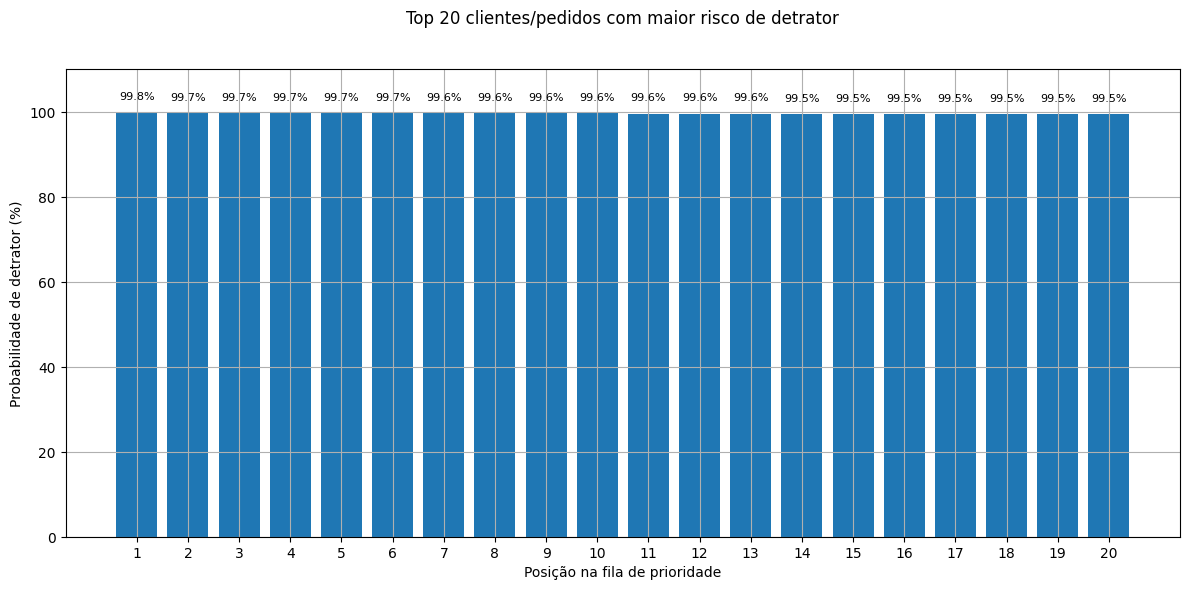

In [27]:
top_n = 20
top_risk = priority_view.head(top_n).copy()

plt.figure(figsize=(12, 6))

plt.bar(
    top_risk["priority_rank"].astype(str),
    top_risk["risk_score_percent"]
)

plt.title("Top 20 clientes/pedidos com maior risco de detrator", y=1.08)
plt.xlabel("Posição na fila de prioridade")
plt.ylabel("Probabilidade de detrator (%)")
plt.ylim(0, 110)

for i, value in enumerate(top_risk["risk_score_percent"]):
    plt.text(i, value + 3, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# Criar recomendação automática de ação

Agora vamos transformar a faixa de risco em uma ação recomendada.

In [28]:
def recommend_action(risk_level):
    if risk_level == "Crítico":
        return "Contato humano prioritário + análise imediata do pedido"
    elif risk_level == "Alto":
        return "Contato preventivo + acompanhamento da jornada"
    elif risk_level == "Médio":
        return "Comunicação automatizada + monitoramento"
    else:
        return "Fluxo padrão sem intervenção imediata"

priority_queue["recommended_action"] = priority_queue["risk_level"].apply(recommend_action)

action_view_cols = [
    "priority_rank",
    "risk_level",
    "risk_score_percent",
    "recommended_action"
]

for col in possible_operational_cols:
    if col in priority_queue.columns:
        action_view_cols.append(col)

action_view = priority_queue[action_view_cols].copy()

display(action_view.head(20))

,priority_rank,risk_level,risk_score_percent,recommended_action,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days,order_value,delivery_attempts
0,1,Crítico,99.761,Contato humano prioritário + análise imediata ...,4,5,2,11,562.800,1
1,2,Crítico,99.732,Contato humano prioritário + análise imediata ...,5,4,1,10,404.400,2
2,3,Crítico,99.720,Contato humano prioritário + análise imediata ...,3,8,5,8,629.150,1
3,4,Crítico,99.718,Contato humano prioritário + análise imediata ...,4,6,3,4,575.520,1
4,5,Crítico,99.672,Contato humano prioritário + análise imediata ...,5,5,2,3,568.760,2
5,6,Crítico,99.657,Contato humano prioritário + análise imediata ...,4,6,3,11,284.140,2
6,7,Crítico,99.628,Contato humano prioritário + análise imediata ...,4,5,1,8,592.310,1
7,8,Crítico,99.621,Contato humano prioritário + análise imediata ...,6,6,3,3,217.150,3
8,9,Crítico,99.610,Contato humano prioritário + análise imediata ...,5,7,3,3,135.240,2
9,10,Crítico,99.610,Contato humano prioritário + análise imediata ...,4,4,2,11,427.380,1


# Distribuição das ações recomendadas

In [29]:
action_distribution = (
    priority_queue["recommended_action"]
    .value_counts()
    .reset_index()
)

action_distribution.columns = ["Ação recomendada", "Quantidade"]

display(action_distribution)

,Ação recomendada,Quantidade
0,Contato humano prioritário + análise imediata ...,338
1,Fluxo padrão sem intervenção imediata,153
2,Contato preventivo + acompanhamento da jornada,73
3,Comunicação automatizada + monitoramento,61


# Gráfico de ações recomendadas

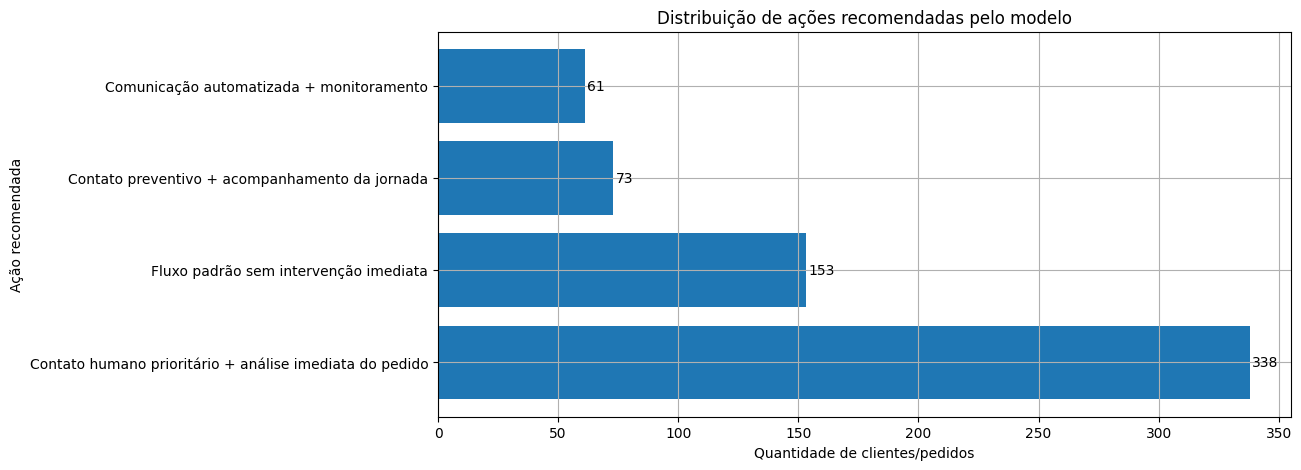

In [30]:
plt.figure(figsize=(11, 5))

plt.barh(
    action_distribution["Ação recomendada"],
    action_distribution["Quantidade"]
)

plt.title("Distribuição de ações recomendadas pelo modelo")
plt.xlabel("Quantidade de clientes/pedidos")
plt.ylabel("Ação recomendada")

for i, value in enumerate(action_distribution["Quantidade"]):
    plt.text(value + 1, i, int(value), va="center")

plt.show()

A distribuição das ações recomendadas mostra como o modelo pode organizar a operação em diferentes níveis de tratamento.

Essa visão é importante porque nem todo cliente em risco exige o mesmo tipo de ação.

Clientes em risco crítico podem justificar intervenção humana imediata, pois representam maior probabilidade de impacto negativo. Já clientes em risco médio podem ser tratados com comunicações automatizadas ou monitoramento, reduzindo custo operacional.

Com isso, o modelo ajuda a balancear dois pontos importantes:

1. reduzir a insatisfação dos clientes com maior risco
2. evitar excesso de intervenção em clientes que não precisam de ação imediata

Essa lógica permite maior eficiência operacional e melhor direcionamento dos recursos da empresa.

# Simulação de capacidade operacional

Aqui vamos simular: “se a operação só consegue tratar X clientes por dia, quem ela deve priorizar?”

In [31]:
daily_capacity       = 50
daily_priority_batch = priority_queue.head(daily_capacity).copy()
print(f"Capacidade simulada: {daily_capacity} clientes/pedidos por dia")

summary_daily_batch = pd.DataFrame({
    "Indicador": ["Total priorizado","Risco medio (%)","Clientes criticos","Risco alto","Detratores reais"],
    "Valor": [
        len(daily_priority_batch),
        daily_priority_batch["risk_score_percent"].mean(),
        (daily_priority_batch["risk_level"] == "Critico").sum(),
        (daily_priority_batch["risk_level"] == "Alto").sum(),
        daily_priority_batch["real_is_detractor"].sum()
    ]
})
display(summary_daily_batch)
display(daily_priority_batch[action_view_cols].head(10))

if "freight_value" in decision_df.columns:
    freight_df = decision_df.copy()
    print(f"\nfreight_df criado: {freight_df.shape[0]} linhas")
else:
    print("⚠️ Coluna freight_value não encontrada no CSV. Verifique o arquivo de dados.")
    freight_df = decision_df.copy()  # fallback: usa decision_df sem coluna de frete

Capacidade simulada: 50 clientes/pedidos por dia


,Indicador,Valor
0,Total priorizado,50.000
1,Risco medio (%),99.429
2,Clientes criticos,0.000
3,Risco alto,0.000
4,Detratores reais,49.000


,priority_rank,risk_level,risk_score_percent,recommended_action,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days,order_value,delivery_attempts
0,1,Crítico,99.761,Contato humano prioritário + análise imediata ...,4,5,2,11,562.800,1
1,2,Crítico,99.732,Contato humano prioritário + análise imediata ...,5,4,1,10,404.400,2
2,3,Crítico,99.720,Contato humano prioritário + análise imediata ...,3,8,5,8,629.150,1
3,4,Crítico,99.718,Contato humano prioritário + análise imediata ...,4,6,3,4,575.520,1
4,5,Crítico,99.672,Contato humano prioritário + análise imediata ...,5,5,2,3,568.760,2
5,6,Crítico,99.657,Contato humano prioritário + análise imediata ...,4,6,3,11,284.140,2
6,7,Crítico,99.628,Contato humano prioritário + análise imediata ...,4,5,1,8,592.310,1
7,8,Crítico,99.621,Contato humano prioritário + análise imediata ...,6,6,3,3,217.150,3
8,9,Crítico,99.610,Contato humano prioritário + análise imediata ...,5,7,3,3,135.240,2
9,10,Crítico,99.610,Contato humano prioritário + análise imediata ...,4,4,2,11,427.380,1



freight_df criado: 625 linhas


A simulação de capacidade operacional demonstra como o modelo pode apoiar a tomada de decisão quando os recursos são limitados.

Na prática, uma empresa nem sempre consegue atuar sobre todos os clientes ao mesmo tempo. Por isso, a priorização é essencial.

Ao ordenar os clientes pelo maior risco, o modelo ajuda a definir quem deve ser tratado primeiro dentro da capacidade disponível da operação.

Esse tipo de abordagem pode ser usado para construir uma fila diária de atuação, por exemplo:

1. top 50 clientes de maior risco por dia
2. clientes críticos com pedido de alto valor
3. clientes com atraso crítico e múltiplas reclamações
4. clientes com maior risco de churn ou baixa recompra

Assim, o modelo contribui para transformar dados em ação operacional concreta.

---
## 8. Uso Operacional: Fila de Priorizacao
> Ranking por risco, acoes recomendadas, simulacao de capacidade diaria.

# Decisão operacional relacionada ao frete

Além do atraso e das reclamações, o valor do frete pode ser usado como uma variável de apoio à decisão operacional.

Clientes que pagam frete mais alto tendem a criar uma expectativa maior sobre a qualidade da entrega. Quando existe frete elevado combinado com atraso, múltiplas tentativas de entrega ou reclamações, o risco de insatisfação pode se tornar mais relevante para o negócio.

Por isso, nesta etapa o objetivo é analisar o frete como critério de decisão, respondendo perguntas como:

1. Clientes com frete mais alto apresentam maior proporção de detratores?
2. Frete alto combinado com atraso aumenta o risco operacional?
3. Quais pedidos deveriam ser priorizados para revisão, compensação ou contato preventivo?
4. O frete pode ser usado como critério complementar na fila de atendimento?

Essa análise não afirma que o frete causa a insatisfação sozinho, mas usa o frete como um sinal adicional para apoiar decisões práticas.

# Criar faixas de frete

In [32]:
freight_values_summary = pd.DataFrame({
    "Indicador": [
        "Menor valor de frete",
        "1º quartil",
        "Mediana",
        "Média",
        "3º quartil",
        "Maior valor de frete"
    ],
    "Valor do frete": [
        freight_df["freight_value"].min(),
        freight_df["freight_value"].quantile(0.25),
        freight_df["freight_value"].median(),
        freight_df["freight_value"].mean(),
        freight_df["freight_value"].quantile(0.75),
        freight_df["freight_value"].max()
    ]
})

freight_values_summary["Valor do frete"] = freight_values_summary["Valor do frete"].map(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

display(freight_values_summary)

,Indicador,Valor do frete
0,Menor valor de frete,"R$ 5,93"
1,1º quartil,"R$ 30,19"
2,Mediana,"R$ 39,72"
3,Média,"R$ 38,85"
4,3º quartil,"R$ 46,50"
5,Maior valor de frete,"R$ 72,67"


A tabela acima apresenta a distribuição dos valores de frete na base analisada.

Essa visão é importante porque permite entender qual é o comportamento típico do frete e identificar a partir de qual faixa o valor pode ser considerado mais elevado em relação ao restante da base.

Neste estudo, o terceiro quartil foi usado como referência para caracterizar frete alto. Isso significa que pedidos acima desse ponto estão entre os 25% maiores valores de frete observados na amostra.

# Faixas reais de frete

In [33]:
freight_df["freight_level"] = pd.qcut(
    freight_df["freight_value"],
    q=4,
    labels=["Frete baixo", "Frete médio-baixo", "Frete médio-alto", "Frete alto"]
)

freight_ranges = (
    freight_df
    .groupby("freight_level", observed=False)
    .agg(
        valor_minimo_frete=("freight_value", "min"),
        valor_maximo_frete=("freight_value", "max"),
        frete_medio=("freight_value", "mean"),
        total_pedidos=("freight_value", "count"),
        percentual_detratores=("real_is_detractor", "mean"),
        risco_medio_modelo=("risk_score_percent", "mean")
    )
    .reset_index()
)

freight_ranges["percentual_detratores"] = freight_ranges["percentual_detratores"] * 100

# Formatação em reais
for col in ["valor_minimo_frete", "valor_maximo_frete", "frete_medio"]:
    freight_ranges[col] = freight_ranges[col].map(
        lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )

display(freight_ranges)

,freight_level,valor_minimo_frete,valor_maximo_frete,frete_medio,total_pedidos,percentual_detratores,risco_medio_modelo
0,Frete baixo,"R$ 5,93","R$ 30,19","R$ 23,55",157,76.433,70.018
1,Frete médio-baixo,"R$ 30,45","R$ 39,72","R$ 35,33",156,69.231,67.072
2,Frete médio-alto,"R$ 39,73","R$ 46,50","R$ 42,90",156,72.436,63.137
3,Frete alto,"R$ 46,55","R$ 72,67","R$ 53,72",156,78.205,71.822


A tabela acima mostra as faixas reais de frete utilizadas na análise.

Com isso, a classificação de frete baixo, médio ou alto deixa de ser abstrata e passa a estar associada a intervalos concretos de valor.

Essa visão ajuda a área de negócio a entender quais pedidos estão em faixas mais sensíveis de custo percebido pelo cliente e como essas faixas se relacionam com a proporção de detratores e com o risco médio previsto pelo modelo.

# Gráfico com frete médio por faixa

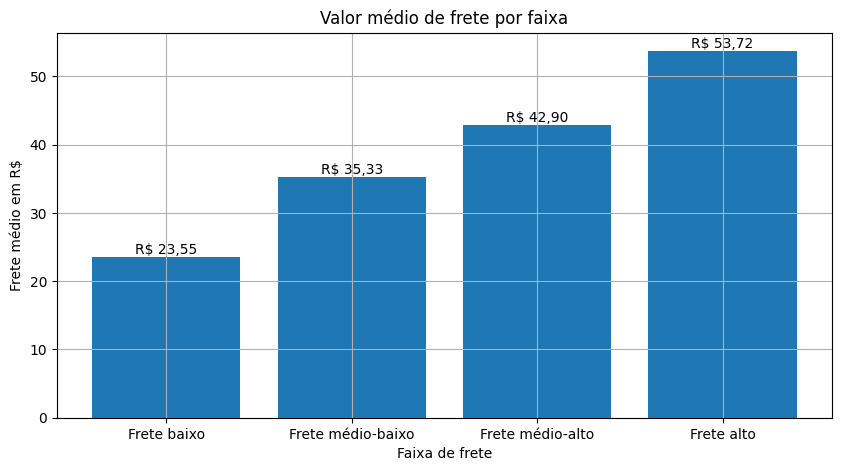

In [34]:
freight_plot_values = (
    freight_df
    .groupby("freight_level", observed=False)
    .agg(frete_medio=("freight_value", "mean"))
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    freight_plot_values["freight_level"].astype(str),
    freight_plot_values["frete_medio"]
)

plt.title("Valor médio de frete por faixa")
plt.xlabel("Faixa de frete")
plt.ylabel("Frete médio em R$")

for i, value in enumerate(freight_plot_values["frete_medio"]):
    label = f"R$ {value:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    plt.text(i, value, label, ha="center", va="bottom")

plt.show()

# Frete alto com valores reais

In [35]:
limiar_frete_alto = freight_df["freight_value"].quantile(0.75)

print(
    "Limiar para considerar frete alto:",
    f"R$ {limiar_frete_alto:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

freight_df["frete_alto"] = freight_df["freight_value"] >= limiar_frete_alto

frete_alto_summary = (
    freight_df
    .groupby("frete_alto")
    .agg(
        total_pedidos=("real_is_detractor", "count"),
        frete_medio=("freight_value", "mean"),
        percentual_detratores=("real_is_detractor", "mean"),
        risco_medio_modelo=("risk_score_percent", "mean")
    )
    .reset_index()
)

frete_alto_summary["frete_alto"] = frete_alto_summary["frete_alto"].map({
    False: "Demais fretes",
    True: "Frete alto"
})

frete_alto_summary["percentual_detratores"] = frete_alto_summary["percentual_detratores"] * 100

frete_alto_summary["frete_medio"] = frete_alto_summary["frete_medio"].map(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

display(frete_alto_summary)

Limiar para considerar frete alto: R$ 46,50


,frete_alto,total_pedidos,frete_medio,percentual_detratores,risco_medio_modelo
0,Demais fretes,468,"R$ 33,87",72.863,66.867
1,Frete alto,157,"R$ 53,68",77.707,71.440


Nesta análise, o conceito de frete alto foi definido com base no terceiro quartil da distribuição dos valores de frete.

Isso significa que o grupo classificado como frete alto representa os pedidos que estão entre os 25% maiores valores de frete da base.

Essa definição evita uma escolha arbitrária e permite criar uma regra objetiva para priorização operacional.

A partir desse ponto, pedidos com frete alto podem ser avaliados em conjunto com outros sinais, como atraso, reclamações, tentativas de entrega e risco preditivo de detrator.

---
## 9. Analise Operacional de Frete
> Faixas por quartil, regras de decisao frete x atraso x score. EDA secao 6.4 e 8.1.

### Solução proposta para o problema relacionado ao frete

A análise do frete deve ser utilizada como uma camada complementar de decisão dentro do modelo preditivo de NPS.

O problema de negócio não está apenas no valor absoluto do frete, mas na combinação entre custo percebido pelo cliente e falhas na jornada de entrega.

Quando um cliente paga um frete mais alto, a expectativa sobre prazo, previsibilidade e qualidade da entrega tende a ser maior. Se esse pedido também apresenta atraso, múltiplas tentativas de entrega, reclamações ou alto risco preditivo de detrator, a chance de insatisfação se torna mais relevante para a operação.

A solução proposta é criar uma regra de priorização específica para pedidos com frete sensível, combinando:

1. Valor do frete
2. Proporção do frete sobre o valor do pedido
3. Atraso de entrega
4. Reclamações acumuladas
5. Tentativas de entrega
6. Score de risco do modelo

Com isso, a empresa pode identificar quais pedidos devem receber revisão operacional, contato preventivo ou possível compensação antes que o cliente registre uma avaliação negativa no NPS.

Essa abordagem permite que o frete deixe de ser apenas um custo logístico e passe a ser tratado como um sinal de expectativa e risco na experiência do cliente.

# Criar regra de decisão para frete

In [36]:
freight_decision_df = decision_df.copy()

freight_decision_df["freight_ratio"] = np.where(
    freight_decision_df["order_value"] > 0,
    freight_decision_df["freight_value"] / freight_decision_df["order_value"], np.nan
)
lim = freight_decision_df["freight_value"].quantile(0.75)
lim_r = freight_decision_df["freight_ratio"].quantile(0.75)

freight_decision_df["frete_alto"]             = freight_decision_df["freight_value"] >= lim
freight_decision_df["frete_pesado_no_pedido"] = freight_decision_df["freight_ratio"] >= lim_r
freight_decision_df["possui_atraso"]          = freight_decision_df["delivery_delay_days"] > 0
freight_decision_df["atraso_critico"]         = freight_decision_df["delivery_delay_days"] >= 3
freight_decision_df["possui_reclamacao"]      = freight_decision_df["complaints_count"] > 0
freight_decision_df["risco_alto_modelo"]      = freight_decision_df["risk_level"].isin(["Critico","Alto"])

def freight_decision_rule(row):
    if row["frete_alto"] and row["atraso_critico"] and row["risco_alto_modelo"]:
        return "Prioridade maxima: contato humano e avaliar compensacao de frete"
    elif row["frete_alto"] and row["possui_atraso"] and row["risco_alto_modelo"]:
        return "Alta prioridade: contato preventivo e acompanhamento logistico"
    elif row["frete_pesado_no_pedido"] and row["possui_reclamacao"]:
        return "Prioridade media: revisar percepcao de custo e atendimento"
    elif row["frete_alto"] and row["risco_alto_modelo"]:
        return "Monitorar: frete alto com risco elevado sem falha logistica"
    else:
        return "Sem acao especifica de frete"

freight_decision_df["decisao_sobre_frete"] = freight_decision_df.apply(freight_decision_rule, axis=1)

base_cols = ["risk_level","risk_score_percent","freight_value","freight_ratio",
             "delivery_delay_days","complaints_count","decisao_sobre_frete","real_is_detractor"]
if "delivery_attempts" in freight_decision_df.columns:
    base_cols.insert(6,"delivery_attempts")
display(freight_decision_df[base_cols].head(20))

,risk_level,risk_score_percent,freight_value,freight_ratio,delivery_delay_days,complaints_count,delivery_attempts,decisao_sobre_frete,real_is_detractor
456,Alto,62.070,20.200,0.020,1,5,3,Sem acao especifica de frete,1
1171,Baixo,13.113,23.250,0.110,1,2,2,Sem acao especifica de frete,0
1363,Baixo,3.993,43.230,0.628,0,1,3,Prioridade media: revisar percepcao de custo e...,0
1043,Baixo,37.413,42.260,0.061,2,2,1,Sem acao especifica de frete,1
1537,Baixo,8.687,44.670,0.049,1,2,1,Sem acao especifica de frete,0
1784,Baixo,28.366,32.130,0.055,2,4,3,Sem acao especifica de frete,1
2442,Crítico,92.018,50.210,0.061,3,4,3,Sem acao especifica de frete,1
2184,Médio,49.088,41.510,0.117,1,6,1,Sem acao especifica de frete,0
1956,Médio,48.586,55.220,0.154,1,4,3,Sem acao especifica de frete,1
2135,Baixo,6.470,30.570,0.767,0,1,3,Prioridade media: revisar percepcao de custo e...,0


# Gráfico das decisões sobre frete

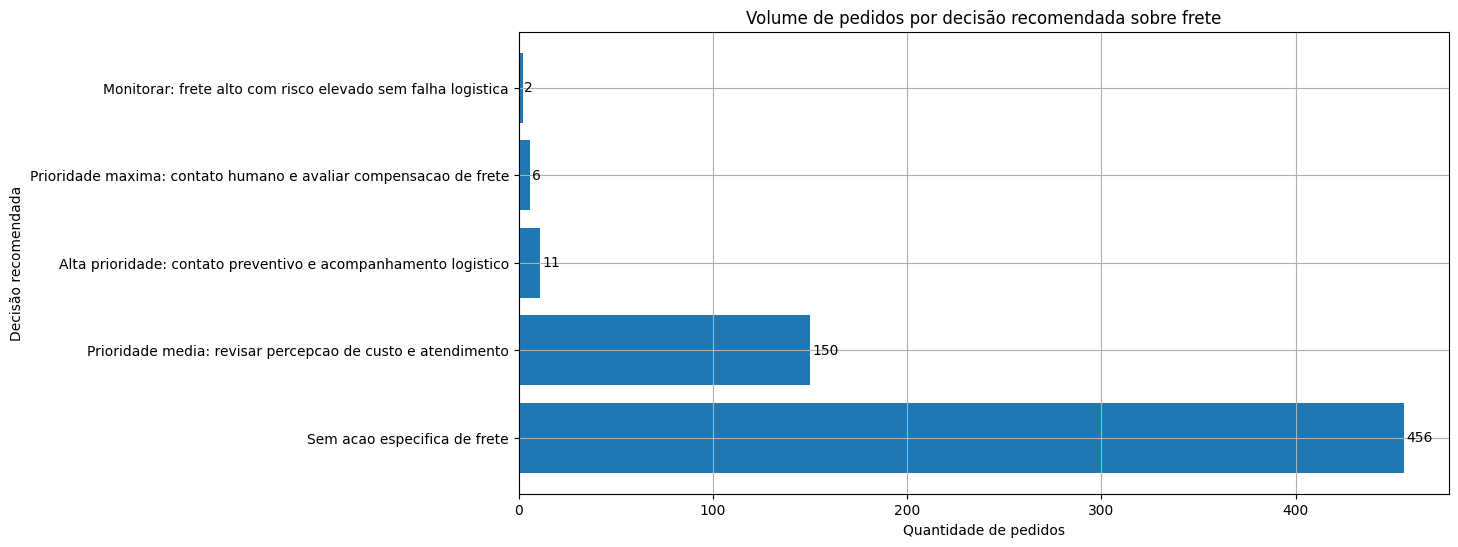

In [37]:
freight_decision_count = (
    freight_decision_df["decisao_sobre_frete"]
    .value_counts()
    .reset_index()
)

freight_decision_count.columns = ["Decisão recomendada", "Quantidade"]

plt.figure(figsize=(12, 6))

plt.barh(
    freight_decision_count["Decisão recomendada"],
    freight_decision_count["Quantidade"]
)

plt.title("Volume de pedidos por decisão recomendada sobre frete")
plt.xlabel("Quantidade de pedidos")
plt.ylabel("Decisão recomendada")

for i, value in enumerate(freight_decision_count["Quantidade"]):
    plt.text(value + 1, i, int(value), va="center")

plt.show()

# Gráfico de detratores por decisão sobre frete

In [38]:
freight_decision_summary = (
    freight_decision_df
    .groupby("decisao_sobre_frete")
    .agg(
        total_pedidos=("real_is_detractor", "count"),
        percentual_detratores=("real_is_detractor", "mean"),
        frete_medio=("freight_value", "mean"),
        atraso_medio=("delivery_delay_days", "mean"),
        reclamacoes_media=("complaints_count", "mean"),
        risco_medio_modelo=("risk_score_percent", "mean")
    )
    .reset_index()
)

freight_decision_summary["percentual_detratores"] = freight_decision_summary["percentual_detratores"] * 100
freight_decision_summary["frete_medio"] = freight_decision_summary["frete_medio"].apply(format_currency_br)

display(freight_decision_summary)

,decisao_sobre_frete,total_pedidos,percentual_detratores,frete_medio,atraso_medio,reclamacoes_media,risco_medio_modelo
0,Alta prioridade: contato preventivo e acompanh...,11,90.909,"R$ 54,95",1.455,4.000,71.885
1,Monitorar: frete alto com risco elevado sem fa...,2,50.000,"R$ 59,03",0.000,6.000,63.577
2,Prioridade maxima: contato humano e avaliar co...,6,66.667,"R$ 52,88",3.167,2.500,72.818
3,Prioridade media: revisar percepcao de custo e...,150,78.667,"R$ 42,52",2.173,4.367,73.408
4,Sem acao especifica de frete,456,72.368,"R$ 36,98",2.164,4.044,66.105


# Resumo das decisões sobre frete

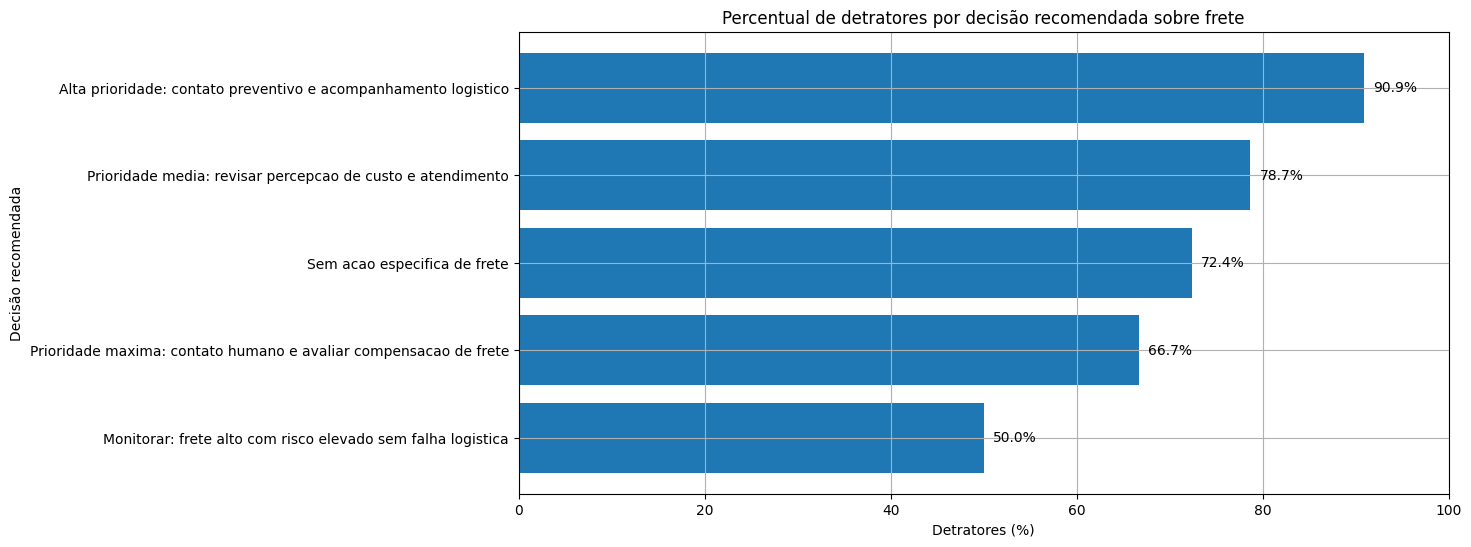

In [39]:
freight_decision_detractor = freight_decision_summary.sort_values(
    by="percentual_detratores",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    freight_decision_detractor["decisao_sobre_frete"],
    freight_decision_detractor["percentual_detratores"]
)

plt.title("Percentual de detratores por decisão recomendada sobre frete")
plt.xlabel("Detratores (%)")
plt.ylabel("Decisão recomendada")
plt.xlim(0, 100)

for i, value in enumerate(freight_decision_detractor["percentual_detratores"]):
    plt.text(value + 1, i, f"{value:.1f}%", va="center")

plt.show()

### Como o modelo apoia decisões reais relacionadas ao frete

O modelo ajuda a empresa a transformar o frete em um critério operacional de decisão.

Sem o modelo, a área de negócio poderia olhar apenas para o valor do frete de forma isolada. Porém, isso não é suficiente para priorizar ações, porque um frete alto nem sempre significa insatisfação.

Com o modelo, a decisão passa a considerar o contexto completo da jornada.

A empresa consegue diferenciar cenários como:

| Cenário | Decisão apoiada pelo modelo |
|---|---|
| Frete alto + atraso crítico + risco alto | Priorizar contato humano e avaliar compensação |
| Frete alto + atraso leve + risco alto | Acompanhar entrega e comunicar cliente preventivamente |
| Frete alto + reclamação | Escalar atendimento e revisar causa da reclamação |
| Frete alto sem atraso e baixo risco | Não agir imediatamente, apenas monitorar |
| Frete baixo com risco crítico | Tratar pelo risco do modelo, não pelo frete |

Essa visão evita decisões genéricas, como compensar todos os clientes com frete alto ou ignorar completamente o impacto do frete na experiência.

O modelo permite priorizar os casos em que o frete aparece combinado com sinais reais de quebra de expectativa, como atraso, reclamação e alto risco de detrator.

Na prática, ele pode apoiar decisões como:

1. quais pedidos devem receber contato preventivo
2. quando avaliar reembolso ou compensação parcial do frete
3. quais entregas devem ser priorizadas pela logística
4. quais clientes devem ser acompanhados pelo atendimento
5. quais regiões, rotas ou transportadoras devem ser investigadas
6. quando o frete deve ser tratado como fator de risco na experiência

Assim, a solução proposta não é simplesmente reduzir o frete, mas usar o frete como sinal de priorização inteligente dentro da jornada do cliente.

# Criar cenário simplificado de ROI

Agora uma simulação executiva simples. Ela não é “verdade final”, é estimativa inicial.

In [40]:
custo_intervencao            = 15.00
custo_estimado_perda_cliente = 120.00
taxa_sucesso_intervencao     = 0.20

intervention_group = priority_queue[priority_queue["risk_level"].isin(["Critico","Alto"])].copy()
qtd_intervencoes               = len(intervention_group)
custo_total                    = qtd_intervencoes * custo_intervencao
clientes_recuperados           = qtd_intervencoes * taxa_sucesso_intervencao
valor_preservado               = clientes_recuperados * custo_estimado_perda_cliente
roi_estimado                   = valor_preservado - custo_total

money_cols = ["Custo por intervencao","Custo total","Custo de perda por cliente","Valor preservado","ROI estimado"]
roi_summary = pd.DataFrame({
    "Premissa/Indicador": [
        "Clientes elegiveis","Custo por intervencao","Custo total",
        "Taxa de sucesso","Clientes recuperados","Custo de perda por cliente",
        "Valor preservado","ROI estimado"
    ],
    "Valor": [qtd_intervencoes,custo_intervencao,custo_total,taxa_sucesso_intervencao,
              clientes_recuperados,custo_estimado_perda_cliente,valor_preservado,roi_estimado]
})
def fmt(ind,val):
    if ind in money_cols: return format_currency_br(val)
    if ind == "Taxa de sucesso": return f"{val:.2%}"
    return f"{int(val):d}"
roi_summary["Valor formatado"] = [fmt(r["Premissa/Indicador"],r["Valor"]) for _,r in roi_summary.iterrows()]
display(roi_summary[["Premissa/Indicador","Valor formatado"]])

,Premissa/Indicador,Valor formatado
0,Clientes elegiveis,73
1,Custo por intervencao,"R$ 15,00"
2,Custo total,"R$ 1.095,00"
3,Taxa de sucesso,20.00%
4,Clientes recuperados,14
5,Custo de perda por cliente,"R$ 120,00"
6,Valor preservado,"R$ 1.752,00"
7,ROI estimado,"R$ 657,00"


# Gráfico do ROI estimado

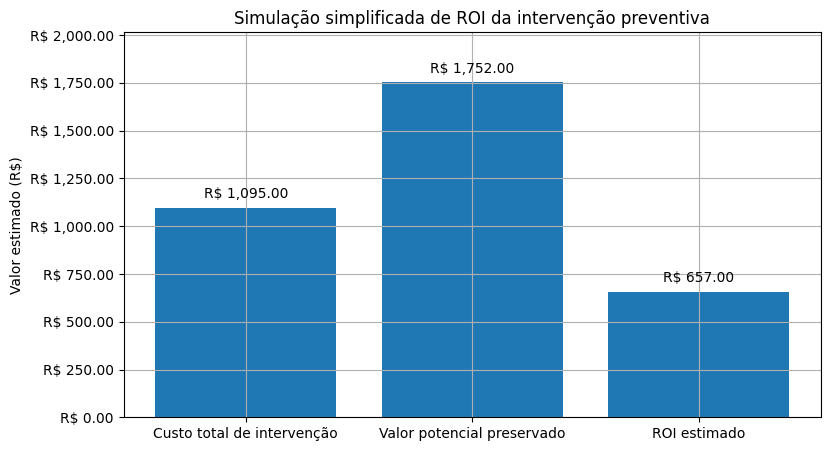

In [41]:
from matplotlib.ticker import FuncFormatter

roi_plot = pd.DataFrame({
    "Categoria": [
        "Custo total de intervenção",
        "Valor potencial preservado",
        "ROI estimado"
    ],
    "Valor": [
        custo_total,
        valor_preservado,
        roi_estimado
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    roi_plot["Categoria"],
    roi_plot["Valor"]
)

plt.title("Simulação simplificada de ROI da intervenção preventiva")
plt.ylabel("Valor estimado (R$)")

# Define a formatter function for currency
def currency_formatter(x, pos):
    return f'R$ {x:,.2f}'

# Apply the formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))

# Set y-axis limits for better spacing and to accommodate labels
max_val = roi_plot["Valor"].max()
plt.ylim(0, max_val * 1.15) # 15% padding above max value

for i, value in enumerate(roi_plot["Valor"]):
    plt.text(i, value + (max_val * 0.02), f"R$ {value:,.2f}", ha="center", va="bottom")

plt.show()

A simulação de ROI tem como objetivo demonstrar como o modelo pode apoiar uma discussão financeira inicial.

As premissas utilizadas nesta simulação são ajustáveis e devem ser validadas com as áreas de negócio.

A lógica é comparar:

1. o custo de realizar uma intervenção preventiva
2. o custo estimado de perder ou insatisfazer um cliente
3. a taxa esperada de sucesso da intervenção

Mesmo que a taxa de sucesso seja conservadora, o modelo pode gerar valor se permitir que a empresa atue nos clientes com maior probabilidade de impacto negativo.

Essa análise ajuda a justificar financeiramente a solução e apoia a priorização de investimentos em atendimento, logística e experiência do cliente.

# Tabela executiva: decisão real apoiada pelo modelo

In [42]:
decision_support_table = pd.DataFrame({
    "Decisão real": [
        "Quem tratar primeiro?",
        "Quando acionar atendimento humano?",
        "Quando usar automação?",
        "Onde priorizar logística?",
        "Como justificar investimento?",
        "Como medir resultado?"
    ],
    "Como o modelo apoia": [
        "Ordena clientes pelo maior risco de detrator",
        "Indica clientes em risco crítico ou alto",
        "Direciona clientes de risco médio para ações de menor custo",
        "Evidencia pedidos com risco elevado e sinais operacionais negativos",
        "Permite estimar custo de intervenção vs perda potencial",
        "Permite comparar grupos tratados e não tratados"
    ],
    "Área beneficiada": [
        "Operação / Atendimento",
        "Atendimento / CX",
        "CRM / Marketing / CX",
        "Logística / Operações",
        "Gestão / Finanças",
        "Analytics / Negócio"
    ]
})

display(decision_support_table)

,Decisão real,Como o modelo apoia,Área beneficiada
0,Quem tratar primeiro?,Ordena clientes pelo maior risco de detrator,Operação / Atendimento
1,Quando acionar atendimento humano?,Indica clientes em risco crítico ou alto,Atendimento / CX
2,Quando usar automação?,Direciona clientes de risco médio para ações d...,CRM / Marketing / CX
3,Onde priorizar logística?,Evidencia pedidos com risco elevado e sinais o...,Logística / Operações
4,Como justificar investimento?,Permite estimar custo de intervenção vs perda ...,Gestão / Finanças
5,Como medir resultado?,Permite comparar grupos tratados e não tratados,Analytics / Negócio


### Síntese do uso do modelo para decisão

O modelo pode apoiar decisões reais ao transformar dados operacionais em uma fila priorizada de atuação.

A principal contribuição não está apenas em prever se um cliente será detrator, mas em indicar onde a empresa deve agir primeiro.

Essa visão permite que a operação seja mais seletiva, eficiente e orientada por risco.

Em vez de tratar todos os clientes da mesma forma, a empresa passa a priorizar aqueles com maior probabilidade de gerar impacto negativo para o NPS, para a retenção e para a reputação da marca.

Com isso, o modelo se torna uma ferramenta prática de apoio à decisão, conectando ciência de dados com ação operacional e valor de negócio.

## Monitoramento e evolução em produção

Para que o modelo seja utilizado de forma confiável em produção, não basta apenas treiná-lo e avaliar suas métricas iniciais.

Modelos preditivos dependem do comportamento histórico dos dados. Caso a operação mude, o comportamento dos clientes também pode mudar, reduzindo a capacidade preditiva do modelo.

Por isso, é necessário implementar uma rotina de monitoramento e evolução contínua.

Neste projeto, os principais pontos de monitoramento são:

1. Performance do modelo ao longo do tempo
2. Mudança na distribuição das variáveis de entrada
3. Mudança na proporção de detratores
4. Estabilidade do score de risco
5. Resultado das ações preventivas
6. Necessidade de retreinamento

Essa etapa garante que o modelo continue útil para apoiar decisões reais de negócio.

# Criar base simulada para monitoramento

Aqui vamos simular uma visão de produção usando a própria base. Como não temos dados históricos separados por mês no dataset, vamos criar um agrupamento simulado para demonstrar a lógica.

In [43]:
monitoring_df = decision_df.copy().reset_index(drop=True)
monitoring_df["periodo"] = pd.qcut(
    range(len(monitoring_df)), q=4,
    labels=["Periodo 1","Periodo 2","Periodo 3","Periodo 4"],
    duplicates="drop"
)
monitoring_df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,atraso_critico,reclamacao_alta,multiplos_contatos,atraso_x_reclamacao,freight_ratio,real_is_detractor,predicted_is_detractor,risk_score,risk_score_percent,risk_level,periodo
0,457,38,Sul,2,50457,1003.780,6,8.750,7,13,1,20.200,3,3,3,5,0,1,1,5,0.020,1,1,0.621,62.070,Alto,Periodo 1
1,1172,65,Sudeste,81,51172,212.060,2,20.220,4,14,1,23.250,2,1,6,2,0,0,0,2,0.110,0,0,0.131,13.113,Baixo,Periodo 1
2,1364,24,Centro-Oeste,35,51364,68.850,1,140.730,9,13,0,43.230,3,0,4,1,0,0,0,0,0.628,0,0,0.040,3.993,Baixo,Periodo 1
3,1044,56,Sul,31,51044,688.360,5,77.190,5,4,2,42.260,1,0,10,2,0,0,0,4,0.061,1,0,0.374,37.413,Baixo,Periodo 1
4,1538,42,Sul,102,51538,908.390,4,26.940,9,4,1,44.670,1,1,2,2,0,0,0,2,0.049,0,0,0.087,8.687,Baixo,Periodo 1


# Monitoramento da proporção de detratores por período

In [44]:
detrator_rate_by_period = (
    monitoring_df.groupby("periodo", observed=True)["real_is_detractor"]
    .mean().mul(100).reset_index()
)
detrator_rate_by_period.columns = ["Periodo","Percentual de detratores reais"]
display(detrator_rate_by_period)

,Periodo,Percentual de detratores reais
0,Periodo 1,75.159
1,Periodo 2,73.077
2,Periodo 3,75.641
3,Periodo 4,72.436


---
## 10. ROI e Decisao Executiva
> R$15/intervencao, R$120/perda, 20% sucesso. Tabela de decisoes por area.

# Gráfico da proporção de detratores por período

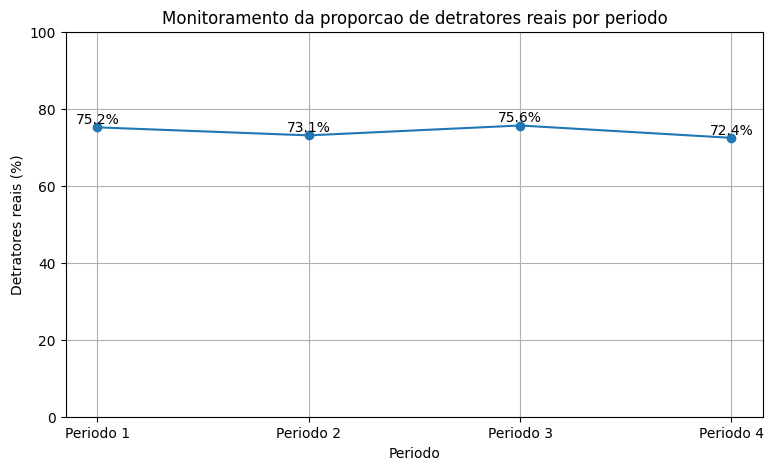

In [45]:
plt.figure(figsize=(9,5))
periodos = detrator_rate_by_period["Periodo"].astype(str).tolist()
valores  = detrator_rate_by_period["Percentual de detratores reais"].tolist()
plt.plot(periodos, valores, marker="o")
plt.title("Monitoramento da proporcao de detratores reais por periodo")
plt.xlabel("Periodo"); plt.ylabel("Detratores reais (%)"); plt.ylim(0,100)
for i,v in enumerate(valores): plt.text(i, v+1, f"{v:.1f}%", ha="center")
plt.show()

O monitoramento da proporção de detratores é importante porque o modelo foi treinado em uma base com alta concentração de clientes insatisfeitos.

Se a operação melhorar e a proporção de detratores diminuir, o comportamento aprendido pelo modelo pode deixar de representar corretamente o cenário atual.

Da mesma forma, se a proporção de detratores aumentar, isso pode indicar deterioração operacional e necessidade de investigação.

Esse indicador ajuda a responder uma pergunta crítica:

> O cenário de negócio continua parecido com aquele usado para treinar o modelo?

# Monitoramento do score médio de risco

In [46]:
risk_score_by_period = (
    monitoring_df.groupby("periodo", observed=True)["risk_score_percent"]
    .mean().reset_index()
)
risk_score_by_period.columns = ["Periodo","Score medio de risco"]
display(risk_score_by_period)

,Periodo,Score medio de risco
0,Periodo 1,67.180
1,Periodo 2,69.400
2,Periodo 3,67.474
3,Periodo 4,68.014


# Gráfico do score médio de risco

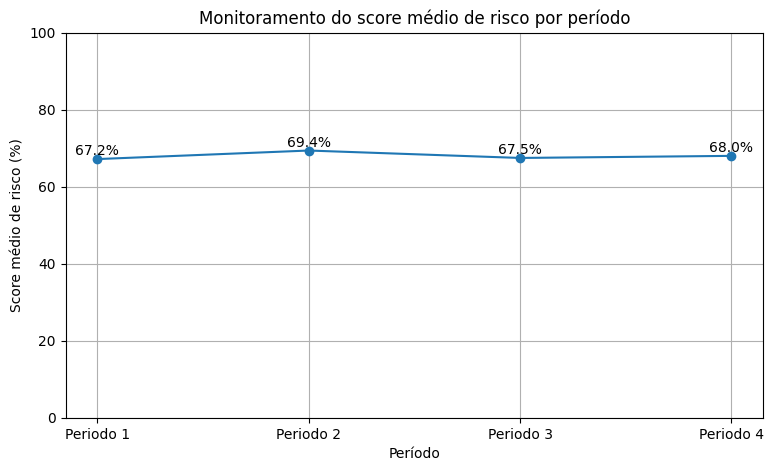

In [47]:
plt.figure(figsize=(9, 5))

plt.plot(
    risk_score_by_period["Periodo"].astype(str),
    risk_score_by_period["Score medio de risco"],
    marker="o"
)

plt.title("Monitoramento do score médio de risco por período")
plt.xlabel("Período")
plt.ylabel("Score médio de risco (%)")
plt.ylim(0, 100)

for i, value in enumerate(risk_score_by_period["Score medio de risco"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

O score médio de risco mostra como o modelo está avaliando a base ao longo do tempo.

Se o score médio começar a subir, isso pode indicar maior concentração de clientes em risco. Se cair de forma significativa, pode indicar melhoria operacional ou mudança no perfil dos dados.

Esse indicador também ajuda a identificar possíveis problemas de calibração do modelo.

Por exemplo, se o score médio continuar alto mesmo quando o percentual real de detratores diminuir, o modelo pode estar superestimando o risco e precisar de recalibração ou retreinamento.

# Monitoramento de variáveis operacionais principais

Vamos monitorar as variáveis que no estudo apareceram como drivers importantes. O código verifica se elas existem na base antes de usar.

In [48]:
# Colunas corretas do CSV (alinhadas com EDA):
# customer_service_contacts (nao customer_service_contacts)
# resolution_time_days      (nao resolution_time_days)
monitoring_features = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
    "resolution_time_days"
]
available_monitoring_features = [c for c in monitoring_features if c in monitoring_df.columns]
feature_monitoring = (
    monitoring_df.groupby("periodo", observed=True)[available_monitoring_features]
    .mean().reset_index()
)
display(feature_monitoring)

,periodo,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days
0,Periodo 1,2.115,4.159,1.516,5.350
1,Periodo 2,2.141,4.071,1.500,5.526
2,Periodo 3,2.237,4.103,1.609,5.154
3,Periodo 4,2.135,4.115,1.526,5.712


---
## 11. Monitoramento e Evolucao
> Colunas corrigidas: customer_service_contacts, resolution_time_days.

# Gráficos das variáveis operacionais monitoradas

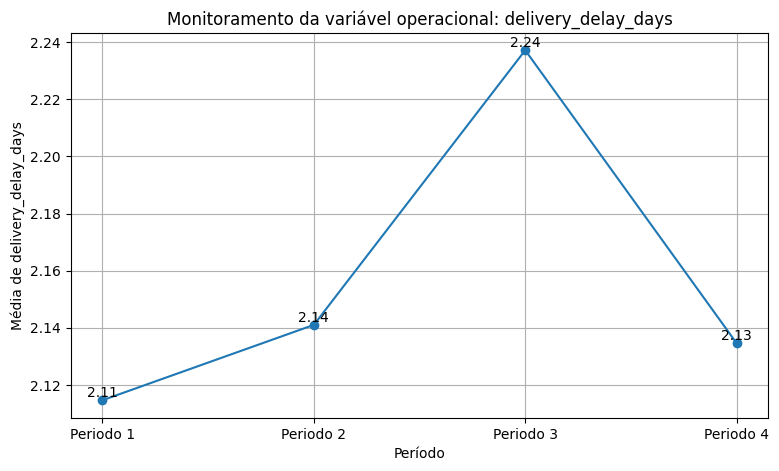

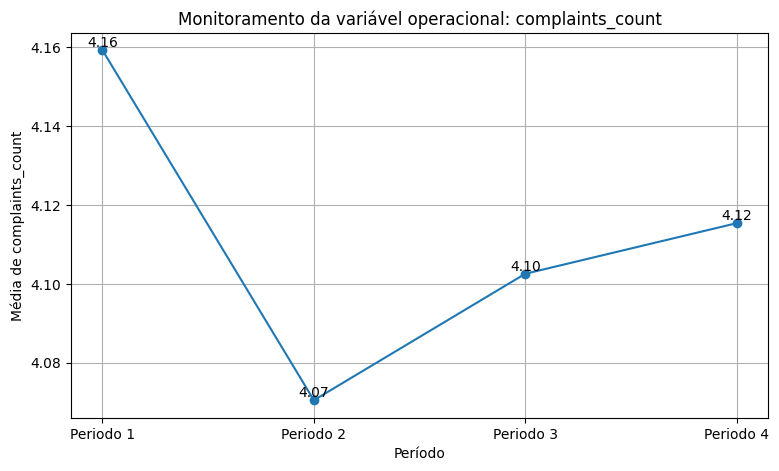

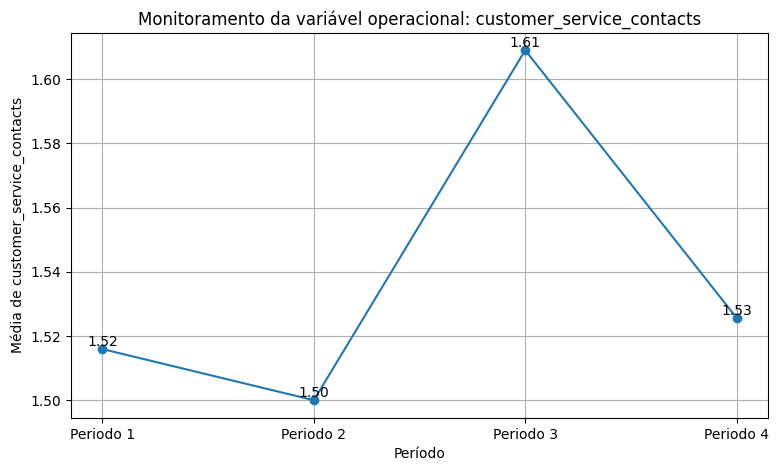

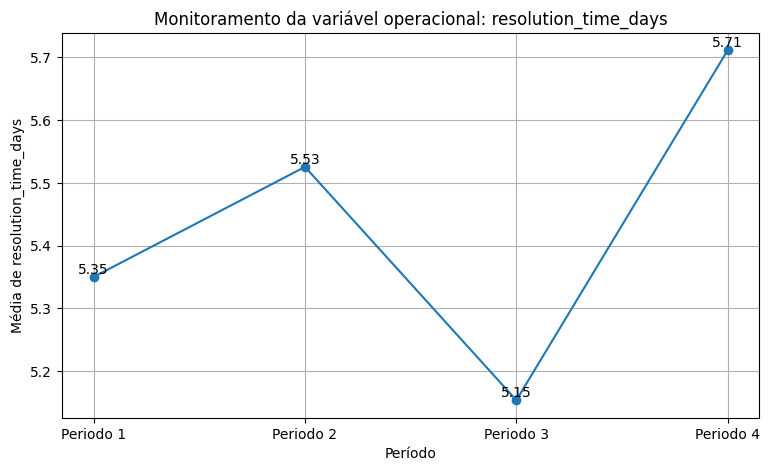

In [49]:
for col in available_monitoring_features:
    plt.figure(figsize=(9, 5))

    plt.plot(
        feature_monitoring["periodo"].astype(str),
        feature_monitoring[col],
        marker="o"
    )

    plt.title(f"Monitoramento da variável operacional: {col}")
    plt.xlabel("Período")
    plt.ylabel(f"Média de {col}")

    for i, value in enumerate(feature_monitoring[col]):
        plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")

    plt.show()

O monitoramento das variáveis operacionais permite identificar mudanças no comportamento da operação.

Neste projeto, variáveis como atraso de entrega, reclamações, contatos com atendimento e tempo de resolução estão diretamente associadas à experiência do cliente.

Se essas variáveis começarem a mudar de forma relevante, o modelo pode passar a operar em um cenário diferente daquele observado no treinamento.

Exemplos:

1. aumento no atraso médio pode indicar problema logístico
2. aumento nas reclamações pode indicar falha recorrente na jornada
3. aumento nos contatos com atendimento pode indicar baixa resolução no primeiro contato
4. aumento no tempo de resolução pode indicar sobrecarga operacional

Esses sinais devem ser acompanhados junto com a performance do modelo.

# Criar tabela de gatilhos de retreinamento

In [50]:
retraining_triggers = pd.DataFrame({
    "Indicador monitorado": [
        "Queda relevante no recall de detratores",
        "Mudança na proporção de detratores",
        "Mudança no score médio de risco",
        "Alteração nas variáveis operacionais",
        "Mudança operacional relevante",
        "Novo volume significativo de dados"
    ],
    "Exemplo de gatilho": [
        "Recall cair abaixo do limite definido pelo negócio",
        "Variação superior a 10 pontos percentuais",
        "Score médio subir ou cair de forma abrupta",
        "Atraso, reclamações ou contatos mudarem de padrão",
        "Novo parceiro logístico, nova política de atendimento ou novo canal",
        "Acúmulo de nova base mensal ou trimestral"
    ],
    "Ação recomendada": [
        "Reavaliar threshold e considerar retreinamento",
        "Revalidar distribuição da base e recalibrar modelo",
        "Investigar calibração e estabilidade das predições",
        "Analisar drift e impacto na performance",
        "Executar nova validação com dados recentes",
        "Retreinar modelo e comparar com versão anterior"
    ]
})

display(retraining_triggers)

,Indicador monitorado,Exemplo de gatilho,Ação recomendada
0,Queda relevante no recall de detratores,Recall cair abaixo do limite definido pelo neg...,Reavaliar threshold e considerar retreinamento
1,Mudança na proporção de detratores,Variação superior a 10 pontos percentuais,Revalidar distribuição da base e recalibrar mo...
2,Mudança no score médio de risco,Score médio subir ou cair de forma abrupta,Investigar calibração e estabilidade das predi...
3,Alteração nas variáveis operacionais,"Atraso, reclamações ou contatos mudarem de padrão",Analisar drift e impacto na performance
4,Mudança operacional relevante,"Novo parceiro logístico, nova política de aten...",Executar nova validação com dados recentes
5,Novo volume significativo de dados,Acúmulo de nova base mensal ou trimestral,Retreinar modelo e comparar com versão anterior


### Validação temporal recomendada

Antes de evoluir o modelo para produção real, recomenda-se aplicar validação temporal.

Na validação tradicional, os dados são divididos aleatoriamente entre treino e teste. Essa abordagem é útil para a etapa inicial, mas não representa perfeitamente um cenário real.

Em produção, o modelo será treinado com dados históricos e usado para prever eventos futuros.

Por isso, a validação temporal deve seguir a lógica:

1. Treinar o modelo com dados de um período anterior
2. Testar o modelo com dados de um período posterior
3. Comparar as métricas com a validação aleatória
4. Avaliar se o modelo mantém performance em dados futuros
5. Definir critérios de retreinamento

Essa etapa reduz o risco de o modelo performar bem apenas na base histórica, mas perder qualidade quando aplicado em dados novos.

#Inferência estatística para validação de impacto do teste A/B

A análise deve comparar um grupo tratamento, composto por clientes priorizados pelo modelo e que receberam intervenção preventiva, com um grupo controle, composto por clientes semelhantes que seguiram o fluxo operacional tradicional.

A estatística entra para responder se a diferença observada entre os grupos pode ser atribuída à intervenção ou se pode ter ocorrido apenas por variação natural dos dados.

Em outras palavras, o teste A/B ajuda a responder:

> A intervenção orientada pelo modelo realmente reduziu a proporção de detratores, melhorou o NPS ou aumentou a retenção?

Para isso, a validação deve considerar:

1. definição correta da população elegível
2. aleatorização dos grupos
3. balanceamento entre tratamento e controle
4. definição prévia das hipóteses
5. cálculo de significância estatística
6. intervalo de confiança
7. tamanho de efeito
8. poder estatístico
9. controle de vieses operacionais

In [51]:
ab_statistical_framework = pd.DataFrame({
    "Etapa estatística": [
        "Desenho experimental",
        "Aleatorização",
        "Balanceamento dos grupos",
        "Definição de hipótese",
        "Teste de significância",
        "Intervalo de confiança",
        "Tamanho de efeito",
        "Poder estatístico",
        "Análise de causalidade",
        "Monitoramento pós-teste"
    ],
    "Aplicação no projeto": [
        "Definir quem será elegível para intervenção preventiva",
        "Separar clientes elegíveis entre tratamento e controle",
        "Garantir grupos comparáveis em risco, atraso, reclamações e valor do pedido",
        "Comparar se a intervenção reduz detratores ou melhora NPS",
        "Avaliar se a diferença observada é estatisticamente significativa",
        "Estimar a faixa provável do impacto real da intervenção",
        "Medir o tamanho prático da melhoria, não apenas o p-valor",
        "Garantir amostra suficiente para detectar o efeito esperado",
        "Avaliar se a mudança pode ser atribuída à intervenção",
        "Verificar se o ganho se mantém ao longo do tempo"
    ],
    "Por que é importante": [
        "Evita testar o modelo em uma população mal definida",
        "Reduz viés de seleção",
        "Evita comparar grupos estruturalmente diferentes",
        "Formaliza o que será considerado sucesso",
        "Diferencia efeito real de variação aleatória",
        "Mostra incerteza da estimativa",
        "Evita concluir impacto relevante apenas por significância",
        "Reduz risco de teste inconclusivo",
        "Aproxima o teste de uma validação causal",
        "Evita ganho pontual sem sustentação operacional"
    ]
})

display(ab_statistical_framework)

,Etapa estatística,Aplicação no projeto,Por que é importante
0,Desenho experimental,Definir quem será elegível para intervenção pr...,Evita testar o modelo em uma população mal def...
1,Aleatorização,Separar clientes elegíveis entre tratamento e ...,Reduz viés de seleção
2,Balanceamento dos grupos,"Garantir grupos comparáveis em risco, atraso, ...",Evita comparar grupos estruturalmente diferentes
3,Definição de hipótese,Comparar se a intervenção reduz detratores ou ...,Formaliza o que será considerado sucesso
4,Teste de significância,Avaliar se a diferença observada é estatistica...,Diferencia efeito real de variação aleatória
5,Intervalo de confiança,Estimar a faixa provável do impacto real da in...,Mostra incerteza da estimativa
6,Tamanho de efeito,"Medir o tamanho prático da melhoria, não apena...",Evita concluir impacto relevante apenas por si...
7,Poder estatístico,Garantir amostra suficiente para detectar o ef...,Reduz risco de teste inconclusivo
8,Análise de causalidade,Avaliar se a mudança pode ser atribuída à inte...,Aproxima o teste de uma validação causal
9,Monitoramento pós-teste,Verificar se o ganho se mantém ao longo do tempo,Evita ganho pontual sem sustentação operacional


# Preparar a base do experimento A/B

In [52]:
from scipy.stats import norm, mannwhitneyu

ab_df = decision_df.copy()
ab_df["nps_score_original"] = df_model.loc[ab_df.index, "nps_score"].values
ab_df = ab_df[ab_df["risk_level"].isin(["Critico","Alto"])].copy()
ab_df = ab_df.sample(frac=1, random_state=42).reset_index(drop=True)
ab_df["ab_group"]          = np.where(ab_df.index < len(ab_df)/2, "Tratamento", "Controle")
ab_df["is_detractor_pre"]  = (ab_df["nps_score_original"] <= 6).astype(int)
ab_df["nps_score_post"]    = ab_df["nps_score_original"].copy()

display(ab_df.head())
print("Total elegiveis:", len(ab_df))
print(ab_df["ab_group"].value_counts())

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,atraso_critico,reclamacao_alta,multiplos_contatos,atraso_x_reclamacao,freight_ratio,real_is_detractor,predicted_is_detractor,risk_score,risk_score_percent,risk_level,nps_score_original,ab_group,is_detractor_pre,nps_score_post
0,2320,67,Sudeste,111,52320,422.860,5,33.250,3,14,2,43.080,1,1,8,4,0,0,0,8,0.102,1,1,0.727,72.653,Alto,0.700,Tratamento,1,0.700
1,560,28,Nordeste,42,50560,140.840,2,78.200,11,5,1,38.300,3,3,0,6,0,1,1,6,0.272,0,1,0.617,61.672,Alto,7.300,Tratamento,0,7.300
2,709,42,Norte,94,50709,248.060,4,123.450,1,2,1,38.670,1,2,1,6,0,1,0,6,0.156,1,1,0.728,72.785,Alto,3.800,Tratamento,1,3.800
3,457,38,Sul,2,50457,1003.780,6,8.750,7,13,1,20.200,3,3,3,5,0,1,1,5,0.020,1,1,0.621,62.070,Alto,2.200,Tratamento,1,2.200
4,1353,62,Sul,62,51353,577.560,5,32.700,2,2,0,49.520,3,4,10,5,0,1,1,0,0.086,0,1,0.614,61.393,Alto,6.100,Tratamento,0,6.100


Total elegiveis: 73
ab_group
Tratamento    37
Controle      36
Name: count, dtype: int64


# Simular o efeito do plano de melhorias

Aqui vamos simular que o plano de melhorias consegue recuperar parte dos detratores do grupo tratamento.

In [53]:
np.random.seed(42)

# Premissa do plano de melhorias
taxa_recuperacao_detratores = 0.18

# Identifica detratores do grupo tratamento
mask_treatment_detractors = (
    (ab_df["ab_group"] == "Tratamento") &
    (ab_df["is_detractor_pre"] == 1)
)

# Simula quais detratores foram recuperados pela intervenção
ab_df["cliente_recuperado"] = 0
ab_df.loc[mask_treatment_detractors, "cliente_recuperado"] = (
    np.random.rand(mask_treatment_detractors.sum()) < taxa_recuperacao_detratores
).astype(int)

# Para clientes recuperados, simula aumento da nota NPS
mask_recovered = ab_df["cliente_recuperado"] == 1

ab_df.loc[mask_recovered, "nps_score_post"] = (
    ab_df.loc[mask_recovered, "nps_score_original"] +
    np.random.randint(1, 4, size=mask_recovered.sum())
)

# Garante que cliente recuperado deixe de ser detrator
ab_df.loc[mask_recovered, "nps_score_post"] = (
    ab_df.loc[mask_recovered, "nps_score_post"]
    .clip(lower=7, upper=10)
)

# Define situação pós-intervenção
ab_df["is_detractor_post"] = (ab_df["nps_score_post"] <= 6).astype(int)

display(
    ab_df[[
        "ab_group", "nps_score_original", "nps_score_post",
        "is_detractor_pre", "is_detractor_post", "cliente_recuperado"
    ]].head(10)
)

,ab_group,nps_score_original,nps_score_post,is_detractor_pre,is_detractor_post,cliente_recuperado
0,Tratamento,0.700,0.700,1,1,0
1,Tratamento,7.300,7.300,0,0,0
2,Tratamento,3.800,3.800,1,1,0
3,Tratamento,2.200,2.200,1,1,0
4,Tratamento,6.100,6.100,0,0,0
5,Tratamento,6.400,6.400,0,0,0
6,Tratamento,3.300,3.300,1,1,0
7,Tratamento,1.000,7.000,1,0,1
8,Tratamento,4.400,7.000,1,0,1
9,Tratamento,9.600,9.600,0,0,0


# Resumo do experimento

In [54]:
ab_summary = (
    ab_df
    .groupby("ab_group", observed=False)
    .agg(
        total_clientes=("ab_group", "count"),
        detratores_pre=("is_detractor_pre", "sum"),
        detratores_post=("is_detractor_post", "sum"),
        taxa_detratores_pre=("is_detractor_pre", "mean"),
        taxa_detratores_post=("is_detractor_post", "mean"),
        nps_medio_pre=("nps_score_original", "mean"),
        nps_medio_post=("nps_score_post", "mean"),
        clientes_recuperados=("cliente_recuperado", "sum")
    )
    .reset_index()
)

ab_summary["taxa_detratores_pre"] = ab_summary["taxa_detratores_pre"] * 100
ab_summary["taxa_detratores_post"] = ab_summary["taxa_detratores_post"] * 100

display(ab_summary)

,ab_group,total_clientes,detratores_pre,detratores_post,taxa_detratores_pre,taxa_detratores_post,nps_medio_pre,nps_medio_post,clientes_recuperados
0,Controle,36,29,29,80.556,80.556,4.586,4.586,0
1,Tratamento,37,29,24,78.378,64.865,4.162,4.681,5


# Taxa de detratores antes e depois

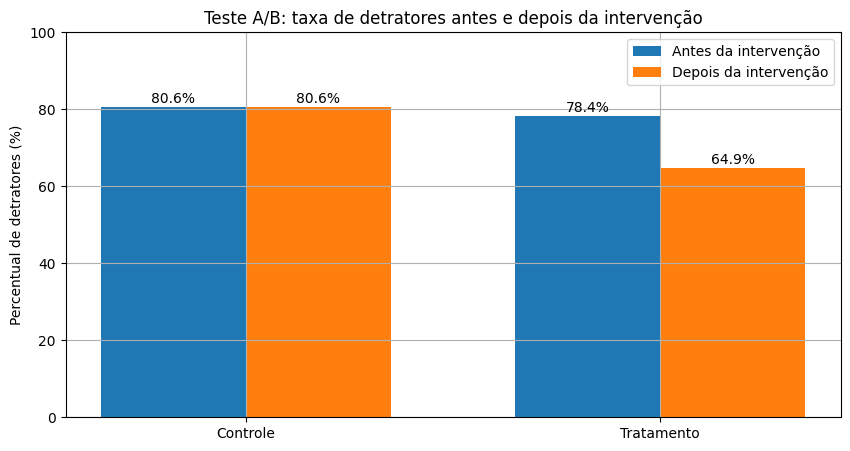

In [55]:
plot_ab_detractors = pd.DataFrame({
    "Grupo": ab_summary["ab_group"],
    "Antes da intervenção": ab_summary["taxa_detratores_pre"],
    "Depois da intervenção": ab_summary["taxa_detratores_post"]
})

x = np.arange(len(plot_ab_detractors))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, plot_ab_detractors["Antes da intervenção"], width, label="Antes da intervenção")
plt.bar(x + width/2, plot_ab_detractors["Depois da intervenção"], width, label="Depois da intervenção")

plt.xticks(x, plot_ab_detractors["Grupo"])
plt.ylabel("Percentual de detratores (%)")
plt.title("Teste A/B: taxa de detratores antes e depois da intervenção")
plt.ylim(0, 100)
plt.legend()

for i, v in enumerate(plot_ab_detractors["Antes da intervenção"]):
    plt.text(i - width/2, v + 1, f"{v:.1f}%", ha="center")

for i, v in enumerate(plot_ab_detractors["Depois da intervenção"]):
    plt.text(i + width/2, v + 1, f"{v:.1f}%", ha="center")

plt.show()

# NPS médio antes e depois

---
## 12. Teste A/B e Inferencia Estatistica
> Proporcao + Mann-Whitney. 18% recuperacao dos detratores tratados.

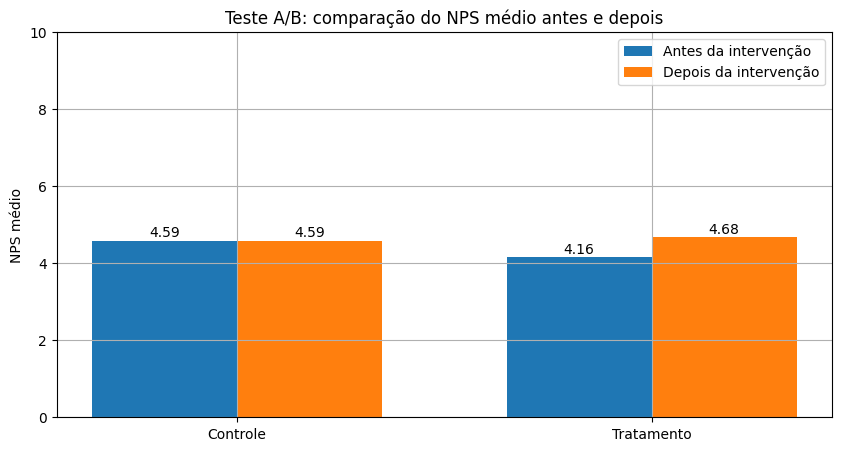

In [56]:
plot_ab_nps = pd.DataFrame({
    "Grupo": ab_summary["ab_group"],
    "Antes da intervenção": ab_summary["nps_medio_pre"],
    "Depois da intervenção": ab_summary["nps_medio_post"]
})

x = np.arange(len(plot_ab_nps))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, plot_ab_nps["Antes da intervenção"], width, label="Antes da intervenção")
plt.bar(x + width/2, plot_ab_nps["Depois da intervenção"], width, label="Depois da intervenção")

plt.xticks(x, plot_ab_nps["Grupo"])
plt.ylabel("NPS médio")
plt.title("Teste A/B: comparação do NPS médio antes e depois")
plt.ylim(0, 10)
plt.legend()

for i, v in enumerate(plot_ab_nps["Antes da intervenção"]):
    plt.text(i - width/2, v + 0.1, f"{v:.2f}", ha="center")

for i, v in enumerate(plot_ab_nps["Depois da intervenção"]):
    plt.text(i + width/2, v + 0.1, f"{v:.2f}", ha="center")

plt.show()

#Taxa de detratores pós-teste com IC 95%

Esse aqui é o gráfico que mostra inferência estatística visualmente.

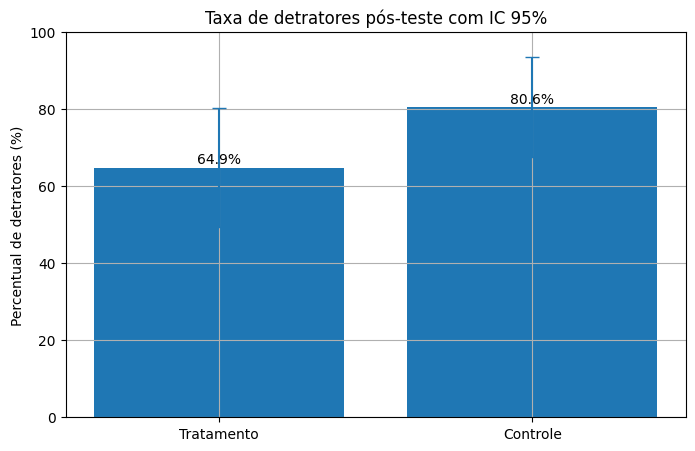

,Grupo,Taxa,IC_inf,IC_sup,erro_inf,erro_sup
0,Tratamento,64.865,49.482,80.248,15.383,15.383
1,Controle,80.556,67.627,93.484,12.929,12.929


In [57]:
def proportion_ci(x, n, z=1.96):
    p = x / n
    se = np.sqrt((p * (1 - p)) / n)
    lower = max(0, p - z * se)
    upper = min(1, p + z * se)
    return p, lower, upper

ci_results = []

for group in ["Tratamento", "Controle"]:
    group_df = ab_df[ab_df["ab_group"] == group]
    x = group_df["is_detractor_post"].sum()
    n = len(group_df)
    p, lower, upper = proportion_ci(x, n)

    ci_results.append({
        "Grupo": group,
        "Taxa": p * 100,
        "IC_inf": lower * 100,
        "IC_sup": upper * 100
    })

ci_df = pd.DataFrame(ci_results)
ci_df["erro_inf"] = ci_df["Taxa"] - ci_df["IC_inf"]
ci_df["erro_sup"] = ci_df["IC_sup"] - ci_df["Taxa"]

plt.figure(figsize=(8, 5))

plt.bar(ci_df["Grupo"], ci_df["Taxa"])
plt.errorbar(
    ci_df["Grupo"],
    ci_df["Taxa"],
    yerr=[ci_df["erro_inf"], ci_df["erro_sup"]],
    fmt="none",
    capsize=5
)

plt.title("Taxa de detratores pós-teste com IC 95%")
plt.ylabel("Percentual de detratores (%)")
plt.ylim(0, 100)

for i, v in enumerate(ci_df["Taxa"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

display(ci_df)

# Distribuição do NPS pós-teste por grupo

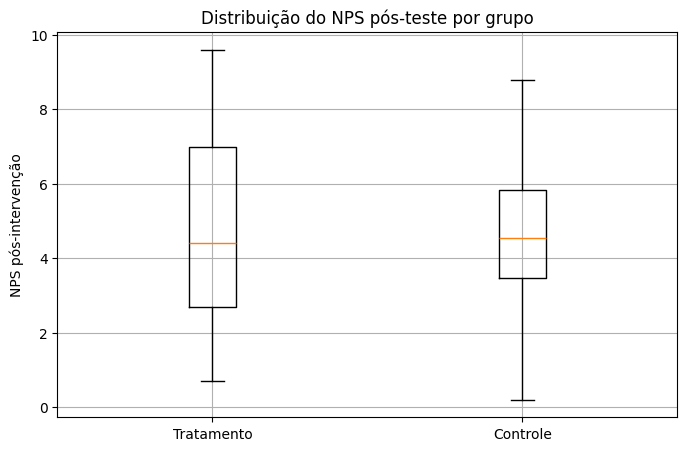

In [58]:
treatment_nps_post = ab_df.loc[ab_df["ab_group"] == "Tratamento", "nps_score_post"]
control_nps_post = ab_df.loc[ab_df["ab_group"] == "Controle", "nps_score_post"]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [treatment_nps_post, control_nps_post],
    tick_labels=["Tratamento", "Controle"]
)

plt.title("Distribuição do NPS pós-teste por grupo")
plt.ylabel("NPS pós-intervenção")

plt.show()

# Teste de inferência para proporção de detratores

In [59]:
treatment_df = ab_df[ab_df["ab_group"] == "Tratamento"]
control_df = ab_df[ab_df["ab_group"] == "Controle"]

x1 = treatment_df["is_detractor_post"].sum()
n1 = len(treatment_df)

x2 = control_df["is_detractor_post"].sum()
n2 = len(control_df)

p1 = x1 / n1
p2 = x2 / n2
p_pool = (x1 + x2) / (n1 + n2)

se_pool = np.sqrt(p_pool * (1 - p_pool) * ((1 / n1) + (1 / n2)))
z_stat = (p1 - p2) / se_pool
p_value_prop = 2 * (1 - norm.cdf(abs(z_stat)))

# IC da diferença
diff = p1 - p2
se_diff = np.sqrt((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2))
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

ab_prop_test = pd.DataFrame({
    "Indicador": [
        "Taxa de detratores - Tratamento",
        "Taxa de detratores - Controle",
        "Diferença absoluta (Tratamento - Controle)",
        "Estatística Z",
        "p-valor",
        "IC 95% da diferença - limite inferior",
        "IC 95% da diferença - limite superior"
    ],
    "Valor": [
        p1,
        p2,
        diff,
        z_stat,
        p_value_prop,
        ci_low,
        ci_high
    ]
})

display(ab_prop_test)

if p_value_prop < 0.05:
    print("Resultado: há evidência estatística de diferença entre os grupos na taxa de detratores.")
else:
    print("Resultado: não há evidência estatística suficiente de diferença entre os grupos na taxa de detratores.")

,Indicador,Valor
0,Taxa de detratores - Tratamento,0.649
1,Taxa de detratores - Controle,0.806
2,Diferença absoluta (Tratamento - Controle),-0.157
3,Estatística Z,-1.503
4,p-valor,0.133
5,IC 95% da diferença - limite inferior,-0.358
6,IC 95% da diferença - limite superior,0.044


Resultado: não há evidência estatística suficiente de diferença entre os grupos na taxa de detratores.


# Teste de inferência para NPS pós-teste

In [60]:
stat_nps, p_value_nps = mannwhitneyu(
    treatment_nps_post,
    control_nps_post,
    alternative="two-sided"
)

ab_nps_test = pd.DataFrame({
    "Indicador": [
        "NPS médio pós - Tratamento",
        "NPS médio pós - Controle",
        "Estatística U",
        "p-valor"
    ],
    "Valor": [
        treatment_nps_post.mean(),
        control_nps_post.mean(),
        stat_nps,
        p_value_nps
    ]
})

display(ab_nps_test)

if p_value_nps < 0.05:
    print("Resultado: há evidência estatística de diferença entre os grupos no NPS pós-teste.")
else:
    print("Resultado: não há evidência estatística suficiente de diferença entre os grupos no NPS pós-teste.")

,Indicador,Valor
0,NPS médio pós - Tratamento,4.681
1,NPS médio pós - Controle,4.586
2,Estatística U,653.500
3,p-valor,0.895


Resultado: não há evidência estatística suficiente de diferença entre os grupos no NPS pós-teste.


#Interpretação dos gráficos e da inferência estatística

Os gráficos do teste A/B permitem visualizar o efeito esperado do plano de melhorias quando aplicado aos clientes priorizados pelo modelo.

Nesta simulação, o grupo tratamento representa os clientes que receberam intervenção preventiva, enquanto o grupo controle representa clientes semelhantes que seguiram o fluxo operacional padrão.

A comparação entre os grupos permite observar:

1. variação na taxa de detratores antes e depois da intervenção
2. mudança no NPS médio
3. diferença visual entre os grupos com intervalo de confiança
4. distribuição do NPS pós-intervenção

Além da visualização, a inferência estatística foi utilizada para avaliar se a diferença observada entre os grupos é estatisticamente sustentada.

O teste para proporções avalia se houve redução relevante na taxa de detratores.

O teste de Mann-Whitney avalia se houve diferença na distribuição das notas NPS pós-intervenção entre tratamento e controle.

Como esta análise é baseada em simulação, ela não deve ser interpretada como prova real de impacto, mas como demonstração metodológica de como o experimento deve ser conduzido em produção.

Em um cenário real, a empresa deverá registrar explicitamente quem recebeu intervenção, qual ação foi aplicada e quais foram os resultados posteriores, para validar causalmente o efeito do modelo.

# Impacto financeiro e reputacional do problema

Antes de concluir a aplicação do modelo, é importante traduzir o problema de NPS para uma visão executiva de impacto.

Clientes detratores não representam apenas uma nota baixa. Eles podem indicar risco de perda de receita, menor recompra, aumento de reclamações, maior custo operacional, desgaste reputacional e pior percepção da marca.


1. Item da lista
2. Item da lista


Por isso, a conclusão executiva deve mostrar dois pontos:

1. O que o problema atual pode estar impactando para a empresa
2. Como a solução proposta pode ajudar a reduzir esse impacto

Nesta etapa, os valores apresentados são estimativas analíticas construídas a partir da base disponível e de premissas ajustáveis de negócio.

In [61]:
executive_df = df_model.copy()
executive_df["is_detractor"] = np.where(executive_df["nps_score"] <= 6, 1, 0)
executive_df["freight_ratio"] = np.where(
    executive_df["order_value"] > 0,
    executive_df["freight_value"] / executive_df["order_value"], np.nan
)
lim_frete = executive_df["freight_value"].quantile(0.75)
executive_df["frete_alto"]     = executive_df["freight_value"] >= lim_frete
executive_df["possui_atraso"]  = executive_df["delivery_delay_days"] > 0
executive_df["atraso_critico"] = executive_df["delivery_delay_days"] >= 3

money_ind = ["Receita total","Receita detratores","Frete total","Frete detratores","Limiar frete alto"]
pct_ind   = ["Percentual detratores"]

base_summary = pd.DataFrame({
    "Indicador": [
        "Total de pedidos","Total de detratores","Percentual detratores",
        "Receita total","Receita detratores","Frete total","Frete detratores",
        "Limiar frete alto","Pedidos frete alto + atraso","Pedidos atraso critico"
    ],
    "Valor": [
        len(executive_df), executive_df["is_detractor"].sum(),
        executive_df["is_detractor"].mean()*100,
        executive_df["order_value"].sum(),
        executive_df.loc[executive_df["is_detractor"]==1,"order_value"].sum(),
        executive_df["freight_value"].sum(),
        executive_df.loc[executive_df["is_detractor"]==1,"freight_value"].sum(),
        lim_frete,
        (executive_df["frete_alto"] & executive_df["possui_atraso"]).sum(),
        executive_df["atraso_critico"].sum()
    ]
})
base_summary["Valor formatado"] = base_summary.apply(
    lambda r: format_currency_br(r["Valor"]) if r["Indicador"] in money_ind
    else f"{r['Valor']:.1f}%" if r["Indicador"] in pct_ind
    else f"{int(r['Valor'])}", axis=1
)
display(base_summary[["Indicador","Valor formatado"]])

,Indicador,Valor formatado
0,Total de pedidos,2500
1,Total de detratores,1851
2,Percentual detratores,74.0%
3,Receita total,"R$ 1.085.649,35"
4,Receita detratores,"R$ 794.052,06"
5,Frete total,"R$ 95.542,54"
6,Frete detratores,"R$ 71.080,42"
7,Limiar frete alto,"R$ 46,27"
8,Pedidos frete alto + atraso,555
9,Pedidos atraso critico,962


# Indicadores monetários com valores reais da base

In [62]:
receita_total = executive_df["order_value"].sum()
frete_total = executive_df["freight_value"].sum()

receita_detratores = executive_df.loc[
    executive_df["is_detractor"] == 1,
    "order_value"
].sum()

frete_detratores = executive_df.loc[
    executive_df["is_detractor"] == 1,
    "freight_value"
].sum()

receita_detratores_atraso = executive_df.loc[
    (executive_df["is_detractor"] == 1) &
    (executive_df["possui_atraso"]),
    "order_value"
].sum()

receita_detratores_frete_alto_atraso = executive_df.loc[
    (executive_df["is_detractor"] == 1) &
    (executive_df["frete_alto"]) &
    (executive_df["possui_atraso"]),
    "order_value"
].sum()

frete_detratores_frete_alto_atraso = executive_df.loc[
    (executive_df["is_detractor"] == 1) &
    (executive_df["frete_alto"]) &
    (executive_df["possui_atraso"]),
    "freight_value"
].sum()

impacto_monetario_base = pd.DataFrame({
    "Indicador": [
        "Receita total da base",
        "Receita associada a detratores",
        "Frete total pago na base",
        "Frete associado a detratores",
        "Receita de detratores com atraso",
        "Receita de detratores com frete alto + atraso",
        "Frete de detratores com frete alto + atraso"
    ],
    "Valor": [
        receita_total,
        receita_detratores,
        frete_total,
        frete_detratores,
        receita_detratores_atraso,
        receita_detratores_frete_alto_atraso,
        frete_detratores_frete_alto_atraso
    ]
})

impacto_monetario_base["Valor formatado"] = impacto_monetario_base["Valor"].apply(format_currency_br)

display(impacto_monetario_base[["Indicador", "Valor formatado"]])

,Indicador,Valor formatado
0,Receita total da base,"R$ 1.085.649,35"
1,Receita associada a detratores,"R$ 794.052,06"
2,Frete total pago na base,"R$ 95.542,54"
3,Frete associado a detratores,"R$ 71.080,42"
4,Receita de detratores com atraso,"R$ 753.537,56"
5,Receita de detratores com frete alto + atraso,"R$ 187.498,08"
6,Frete de detratores com frete alto + atraso,"R$ 24.280,90"


# Gráfico do impacto monetário

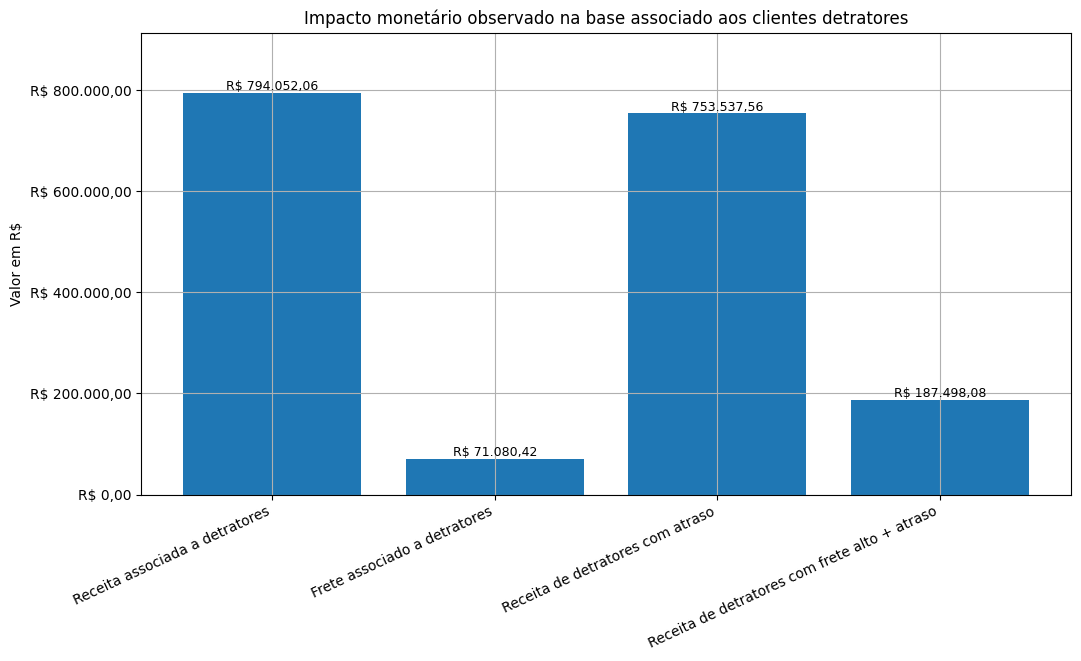

In [63]:
import matplotlib.ticker as mticker

impacto_plot = impacto_monetario_base[
    impacto_monetario_base["Indicador"].isin([
        "Receita associada a detratores",
        "Frete associado a detratores",
        "Receita de detratores com atraso",
        "Receita de detratores com frete alto + atraso"
    ])
].copy()

plt.figure(figsize=(12, 6))

plt.bar(
    impacto_plot["Indicador"],
    impacto_plot["Valor"]
)

plt.title("Impacto monetário observado na base associado aos clientes detratores")
plt.ylabel("Valor em R$")
plt.xticks(rotation=25, ha="right")

# Calculate max value from the current plot's data for proper y-axis scaling
max_val_impact_monetary = impacto_plot["Valor"].max()
plt.ylim(0, max_val_impact_monetary * 1.15) # Add 15% padding above max value

# Define a formatter function for currency
def currency_formatter_plot(x, pos):
    return f'R$ {x:,.2f}'.replace('.', 'X').replace(',', '.').replace('X', ',')

# Apply the formatter to the y-axis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(currency_formatter_plot))

for i, value in enumerate(impacto_plot["Valor"]):
    plt.text(
        i,
        value,
        format_currency_br(value),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

# Impacto reputacional



In [64]:
total_pedidos = len(executive_df)

qtd_detratores = executive_df["is_detractor"].sum()
qtd_promotores = (executive_df["nps_score"] >= 9).sum()
qtd_neutros = total_pedidos - qtd_detratores - qtd_promotores

percentual_detratores = qtd_detratores / total_pedidos * 100
percentual_promotores = qtd_promotores / total_pedidos * 100
percentual_neutros = qtd_neutros / total_pedidos * 100

nps_oficial = percentual_promotores - percentual_detratores

# Reclamações dos detratores
reclamacoes_detratores = executive_df.loc[
    executive_df["is_detractor"] == 1,
    "complaints_count"
].sum()

reclamacoes_total = executive_df["complaints_count"].sum()

percentual_reclamacoes_detratores = (
    reclamacoes_detratores / reclamacoes_total * 100
    if reclamacoes_total > 0 else 0
)

# Índice simples de exposição reputacional
# Quanto maior, mais concentrado está o risco reputacional.
indice_exposicao_reputacional = (
    percentual_detratores * 0.5 +
    percentual_reclamacoes_detratores * 0.3 +
    abs(min(nps_oficial, 0)) * 0.2
)

reputational_impact_summary = pd.DataFrame({
    "Indicador reputacional": [
        "Total de pedidos avaliados",
        "Detratores",
        "Neutros",
        "Promotores",
        "% Detratores",
        "% Neutros",
        "% Promotores",
        "NPS oficial",
        "Reclamações associadas a detratores",
        "% das reclamações em detratores",
        "Índice de exposição reputacional"
    ],
    "Valor": [
        total_pedidos,
        qtd_detratores,
        qtd_neutros,
        qtd_promotores,
        percentual_detratores,
        percentual_neutros,
        percentual_promotores,
        nps_oficial,
        reclamacoes_detratores,
        percentual_reclamacoes_detratores,
        indice_exposicao_reputacional
    ]
})

# Formatação adequada por tipo de indicador
percent_indicators = [
    "% Detratores",
    "% Neutros",
    "% Promotores",
    "% das reclamações em detratores",
    "Índice de exposição reputacional"
]

integer_indicators = [
    "Total de pedidos avaliados",
    "Detratores",
    "Neutros",
    "Promotores",
    "Reclamações associadas a detratores"
]

reputational_impact_summary["Valor formatado"] = reputational_impact_summary.apply(
    lambda row: f"{row['Valor']:.1f}%" if row["Indicador reputacional"] in percent_indicators
    else f"{int(row['Valor'])}" if row["Indicador reputacional"] in integer_indicators
    else f"{row['Valor']:.1f}",
    axis=1
)

display(reputational_impact_summary[["Indicador reputacional", "Valor formatado"]])

,Indicador reputacional,Valor formatado
0,Total de pedidos avaliados,2500
1,Detratores,1851
2,Neutros,539
3,Promotores,110
4,% Detratores,74.0%
5,% Neutros,21.6%
6,% Promotores,4.4%
7,NPS oficial,-69.6
8,Reclamações associadas a detratores,8557
9,% das reclamações em detratores,82.5%


# Gráfico reputacional

> Adicionar aspas



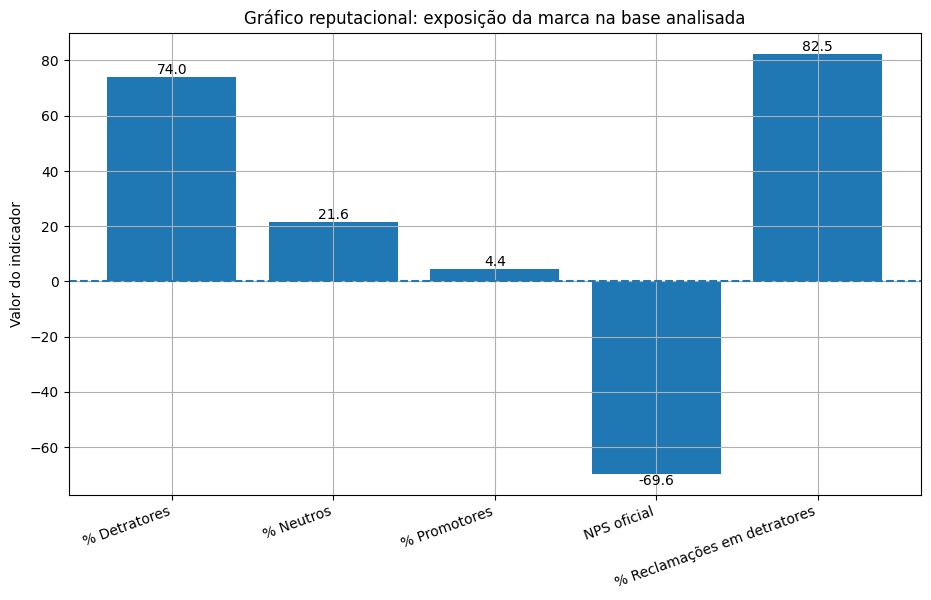

In [65]:
reputational_chart = pd.DataFrame({
    "Indicador": [
        "% Detratores",
        "% Neutros",
        "% Promotores",
        "NPS oficial",
        "% Reclamações em detratores"
    ],
    "Valor": [
        percentual_detratores,
        percentual_neutros,
        percentual_promotores,
        nps_oficial,
        percentual_reclamacoes_detratores
    ]
})

plt.figure(figsize=(11, 6))

plt.bar(
    reputational_chart["Indicador"],
    reputational_chart["Valor"]
)

plt.title("Gráfico reputacional: exposição da marca na base analisada")
plt.ylabel("Valor do indicador")
plt.xticks(rotation=20, ha="right")

for i, value in enumerate(reputational_chart["Valor"]):
    plt.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.axhline(0, linestyle="--")

plt.show()

### Leitura integrada do impacto financeiro e reputacional

A análise financeira e reputacional mostra que o problema de NPS não deve ser tratado apenas como uma métrica de satisfação do cliente.

Na base analisada, os clientes detratores concentram uma parte relevante da receita, do frete pago e das reclamações registradas. Isso significa que a insatisfação está associada a uma exposição real para o negócio, tanto em termos monetários quanto em percepção de marca.

Do ponto de vista financeiro, clientes detratores podem representar risco de perda de recompra, maior custo de atendimento, aumento de reclamações, maior esforço operacional e possível churn. Quando esse cenário aparece combinado com atraso de entrega, frete alto ou múltiplas reclamações, o impacto tende a ser ainda mais sensível para a empresa.

Do ponto de vista reputacional, a alta proporção de detratores reduz a força de recomendação da marca, aumenta o risco de avaliações negativas, amplia a percepção de falha na jornada e pode comprometer a confiança do cliente na experiência de compra.

Portanto, o impacto para o negócio ocorre em duas dimensões complementares:

| Dimensão | Impacto para o negócio | Exemplo na operação |
|---|---|---|
| Financeira | Receita em risco, maior custo de atendimento e possível perda de recompra | Clientes detratores com pedidos de alto valor, frete pago e atraso |
| Reputacional | Perda de confiança, menor recomendação e maior risco de reclamações públicas | Alto percentual de detratores, NPS negativo e reclamações concentradas |
| Operacional | Sobrecarga dos times e pior eficiência na resolução de problemas | Múltiplos contatos, reclamações recorrentes e atrasos críticos |
| Estratégica | Menor previsibilidade sobre retenção e experiência do cliente | Empresa age somente após a resposta negativa do NPS |

Essa leitura reforça que o modelo preditivo não deve ser visto apenas como uma ferramenta analítica. Ele deve ser usado como uma camada de decisão para antecipar riscos, priorizar clientes críticos e reduzir impactos antes que eles se consolidem em perda financeira ou desgaste reputacional.

Em resumo, quanto maior a concentração de detratores sem intervenção preventiva, maior tende a ser a exposição da empresa em receita, operação, reputação e retenção.

# Benefícios esperados das sugestões de melhoria

Para estimar os benefícios esperados das ações propostas, foi considerado um cenário executivo de curto prazo com melhoria mínima esperada de 35% sobre os principais impactos observados.

Essa premissa representa um cenário-alvo para apresentação à diretoria, considerando que o modelo seja integrado à operação e usado para priorizar ações preventivas nos clientes com maior risco de detrator.

A melhoria esperada de 35% será aplicada sobre quatro frentes principais:

1. redução de detratores em grupos críticos
2. redução de reclamações associadas a detratores
3. proteção de receita associada a clientes em risco
4. redução da exposição reputacional

Essa estimativa não deve ser interpretada como resultado já comprovado, mas como uma projeção de benefício esperada a partir da adoção das recomendações propostas. A comprovação real deve ocorrer posteriormente por meio de teste A/B e monitoramento em produção.

In [66]:
# Premissa executiva mínima de melhoria esperada no curto prazo
melhoria_esperada_curto_prazo = 0.35

# Base de atuação: clientes detratores com sinais operacionais críticos
atuacao_df = executive_df[
    (executive_df["is_detractor"] == 1) &
    (
        (executive_df["possui_atraso"]) |
        (executive_df["atraso_critico"]) |
        (executive_df["frete_alto"])
    )
].copy()

# Métricas reais da base de atuação
clientes_impactados = len(atuacao_df)
receita_em_atuacao = atuacao_df["order_value"].sum()
frete_em_atuacao = atuacao_df["freight_value"].sum()
reclamacoes_em_atuacao = atuacao_df["complaints_count"].sum()

# Benefícios estimados com melhoria de 35%
clientes_potencialmente_recuperados = clientes_impactados * melhoria_esperada_curto_prazo
receita_potencialmente_protegida = receita_em_atuacao * melhoria_esperada_curto_prazo
frete_potencialmente_revisado = frete_em_atuacao * melhoria_esperada_curto_prazo
reclamacoes_potencialmente_reduzidas = reclamacoes_em_atuacao * melhoria_esperada_curto_prazo

beneficio_total_monetario = receita_potencialmente_protegida + frete_potencialmente_revisado

executive_target_summary = pd.DataFrame({
    "Indicador": [
        "Melhoria esperada no curto prazo",
        "Clientes detratores elegíveis para atuação",
        "Clientes potencialmente recuperados",
        "Receita na base de atuação",
        "Receita potencialmente protegida",
        "Frete na base de atuação",
        "Frete potencialmente revisado/protegido",
        "Benefício monetário total estimado",
        "Reclamações na base de atuação",
        "Reclamações potencialmente reduzidas"
    ],
    "Valor": [
        melhoria_esperada_curto_prazo,
        clientes_impactados,
        clientes_potencialmente_recuperados,
        receita_em_atuacao,
        receita_potencialmente_protegida,
        frete_em_atuacao,
        frete_potencialmente_revisado,
        beneficio_total_monetario,
        reclamacoes_em_atuacao,
        reclamacoes_potencialmente_reduzidas
    ]
})

money_indicators = [
    "Receita na base de atuação",
    "Receita potencialmente protegida",
    "Frete na base de atuação",
    "Frete potencialmente revisado/protegido",
    "Benefício monetário total estimado"
]

percent_indicators = [
    "Melhoria esperada no curto prazo"
]

executive_target_summary["Valor formatado"] = executive_target_summary.apply(
    lambda row: format_currency_br(row["Valor"]) if row["Indicador"] in money_indicators
    else f"{row['Valor']:.0%}" if row["Indicador"] in percent_indicators
    else f"{row['Valor']:.0f}",
    axis=1
)

display(executive_target_summary[["Indicador", "Valor formatado"]])

,Indicador,Valor formatado
0,Melhoria esperada no curto prazo,35%
1,Clientes detratores elegíveis para atuação,1773
2,Clientes potencialmente recuperados,621
3,Receita na base de atuação,"R$ 762.740,15"
4,Receita potencialmente protegida,"R$ 266.959,05"
5,Frete na base de atuação,"R$ 68.474,52"
6,Frete potencialmente revisado/protegido,"R$ 23.966,08"
7,Benefício monetário total estimado,"R$ 290.925,13"
8,Reclamações na base de atuação,8236
9,Reclamações potencialmente reduzidas,2883


---
## 13. Impacto Financeiro e Reputacional
> Receita em risco, beneficios com 35% de melhoria nos grupos criticos.

# Onde iremos atuar

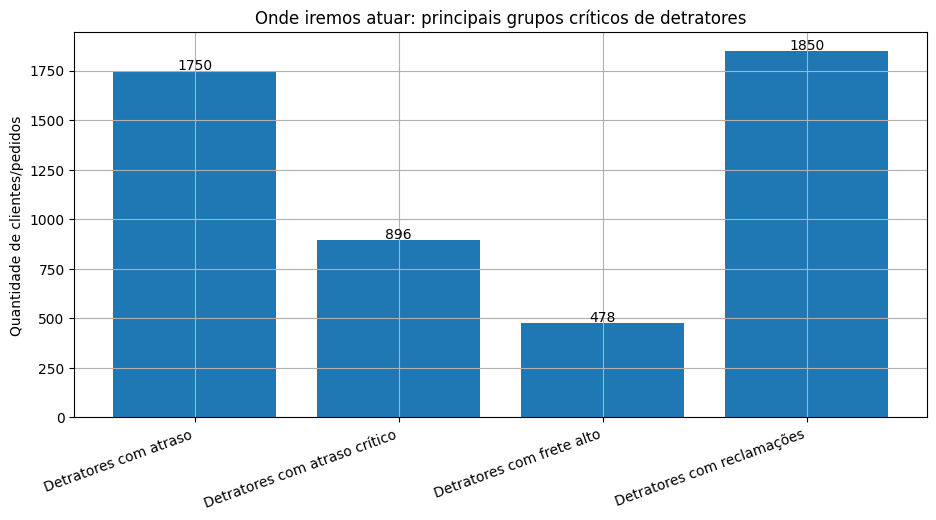

,Frente de atuação,Quantidade
0,Detratores com atraso,1750
1,Detratores com atraso crítico,896
2,Detratores com frete alto,478
3,Detratores com reclamações,1850


In [67]:
areas_atuacao = pd.DataFrame({
    "Frente de atuação": [
        "Detratores com atraso",
        "Detratores com atraso crítico",
        "Detratores com frete alto",
        "Detratores com reclamações"
    ],
    "Quantidade": [
        executive_df[
            (executive_df["is_detractor"] == 1) &
            (executive_df["possui_atraso"])
        ].shape[0],
        executive_df[
            (executive_df["is_detractor"] == 1) &
            (executive_df["atraso_critico"])
        ].shape[0],
        executive_df[
            (executive_df["is_detractor"] == 1) &
            (executive_df["frete_alto"])
        ].shape[0],
        executive_df[
            (executive_df["is_detractor"] == 1) &
            (executive_df["complaints_count"] > 0)
        ].shape[0]
    ]
})

plt.figure(figsize=(11, 5))

plt.bar(
    areas_atuacao["Frente de atuação"],
    areas_atuacao["Quantidade"]
)

plt.title("Onde iremos atuar: principais grupos críticos de detratores")
plt.ylabel("Quantidade de clientes/pedidos")
plt.xticks(rotation=20, ha="right")

for i, value in enumerate(areas_atuacao["Quantidade"]):
    plt.text(i, value + 5, int(value), ha="center")

plt.show()

display(areas_atuacao)

O gráfico acima mostra os principais grupos onde as ações preventivas devem ser concentradas.

A atuação proposta prioriza clientes detratores que apresentam sinais operacionais críticos, como atraso, atraso crítico, frete alto ou reclamações.

Essa priorização é importante porque permite direcionar a operação para os pontos com maior potencial de impacto financeiro e reputacional.

Em vez de atuar de forma genérica sobre toda a base, a solução concentra esforço nos grupos onde a insatisfação já aparece associada a falhas concretas da jornada.

# Gráfico de benefício financeiro esperado

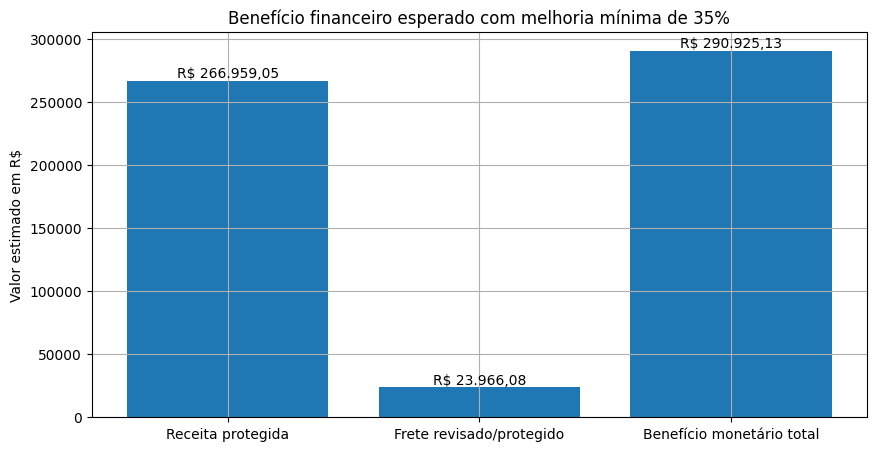

,Benefício financeiro,Valor formatado
0,Receita protegida,"R$ 266.959,05"
1,Frete revisado/protegido,"R$ 23.966,08"
2,Benefício monetário total,"R$ 290.925,13"


In [68]:
financial_benefits_35 = pd.DataFrame({
    "Benefício financeiro": [
        "Receita protegida",
        "Frete revisado/protegido",
        "Benefício monetário total"
    ],
    "Valor": [
        receita_potencialmente_protegida,
        frete_potencialmente_revisado,
        beneficio_total_monetario
    ]
})

plt.figure(figsize=(10, 5))

plt.bar(
    financial_benefits_35["Benefício financeiro"],
    financial_benefits_35["Valor"]
)

plt.title("Benefício financeiro esperado com melhoria mínima de 35%")
plt.ylabel("Valor estimado em R$")

for i, value in enumerate(financial_benefits_35["Valor"]):
    plt.text(i, value, format_currency_br(value), ha="center", va="bottom")

plt.show()

financial_benefits_35_display = financial_benefits_35.copy()
financial_benefits_35_display["Valor formatado"] = financial_benefits_35_display["Valor"].apply(format_currency_br)

display(financial_benefits_35_display[["Benefício financeiro", "Valor formatado"]])

# Benefício reputacional esperado

In [69]:
detratores_evitar_35 = qtd_detratores * melhoria_esperada_curto_prazo
reclamacoes_evitar_35 = reclamacoes_detratores * melhoria_esperada_curto_prazo

novo_qtd_detratores_35 = qtd_detratores - detratores_evitar_35
novo_percentual_detratores_35 = novo_qtd_detratores_35 / total_pedidos * 100

nps_estimado_35 = percentual_promotores - novo_percentual_detratores_35
ganho_nps_35 = nps_estimado_35 - nps_oficial

reputation_benefit_35 = pd.DataFrame({
    "Indicador reputacional": [
        "Detratores atuais",
        "Detratores potencialmente evitados",
        "Detratores estimados após melhoria",
        "Reclamações de detratores atuais",
        "Reclamações potencialmente reduzidas",
        "NPS oficial atual",
        "NPS estimado após melhoria",
        "Ganho estimado de NPS"
    ],
    "Valor": [
        qtd_detratores,
        detratores_evitar_35,
        novo_qtd_detratores_35,
        reclamacoes_detratores,
        reclamacoes_evitar_35,
        nps_oficial,
        nps_estimado_35,
        ganho_nps_35
    ]
})

# Define indicators that should be formatted as integers
integer_indicators_reputational = [
    "Detratores atuais",
    "Detratores potencialmente evitados",
    "Detratores estimados após melhoria",
    "Reclamações de detratores atuais",
    "Reclamações potencialmente reduzidas"
]

# Define indicators that should be formatted as percentages (with one decimal place for NPS values)
percent_indicators_reputational = [
    "NPS oficial atual",
    "NPS estimado após melhoria",
    "Ganho estimado de NPS"
]

reputation_benefit_35["Valor formatado"] = reputation_benefit_35.apply(
    lambda row:
    f"{int(row['Valor'])}" if row["Indicador reputacional"] in integer_indicators_reputational
    else f"{row['Valor']:.1f}" if row["Indicador reputacional"] in percent_indicators_reputational
    else str(row['Valor']),
    axis=1
)

display(reputation_benefit_35[["Indicador reputacional", "Valor formatado"]])

,Indicador reputacional,Valor formatado
0,Detratores atuais,1851
1,Detratores potencialmente evitados,647
2,Detratores estimados após melhoria,1203
3,Reclamações de detratores atuais,8557
4,Reclamações potencialmente reduzidas,2994
5,NPS oficial atual,-69.6
6,NPS estimado após melhoria,-43.7
7,Ganho estimado de NPS,25.9


# Gráfico reputacional antes vs depois

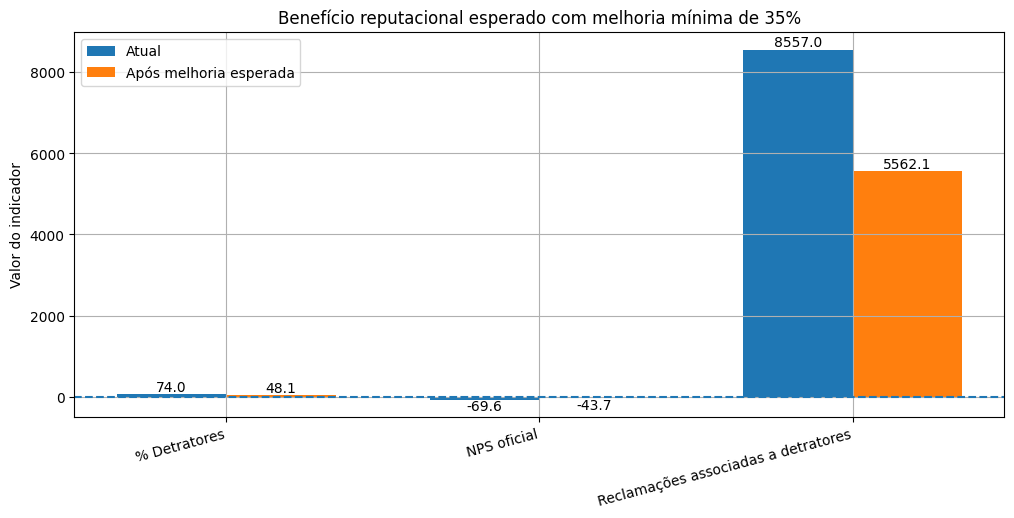

In [70]:
reputation_before_after = pd.DataFrame({
    "Indicador": [
        "% Detratores",
        "NPS oficial",
        "Reclamações associadas a detratores"
    ],
    "Atual": [
        percentual_detratores,
        nps_oficial,
        reclamacoes_detratores
    ],
    "Após melhoria esperada": [
        novo_percentual_detratores_35,
        nps_estimado_35,
        reclamacoes_detratores - reclamacoes_evitar_35
    ]
})

x = np.arange(len(reputation_before_after))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(
    x - width / 2,
    reputation_before_after["Atual"],
    width,
    label="Atual"
)

plt.bar(
    x + width / 2,
    reputation_before_after["Após melhoria esperada"],
    width,
    label="Após melhoria esperada"
)

plt.title("Benefício reputacional esperado com melhoria mínima de 35%")
plt.ylabel("Valor do indicador")
plt.xticks(x, reputation_before_after["Indicador"], rotation=15, ha="right")
plt.legend()

for i, value in enumerate(reputation_before_after["Atual"]):
    plt.text(i - width / 2, value, f"{value:.1f}", ha="center", va="bottom" if value >= 0 else "top")

for i, value in enumerate(reputation_before_after["Após melhoria esperada"]):
    plt.text(i + width / 2, value, f"{value:.1f}", ha="center", va="bottom" if value >= 0 else "top")

plt.axhline(0, linestyle="--")

plt.show()

# Gráfico executivo: financeiro + reputacional

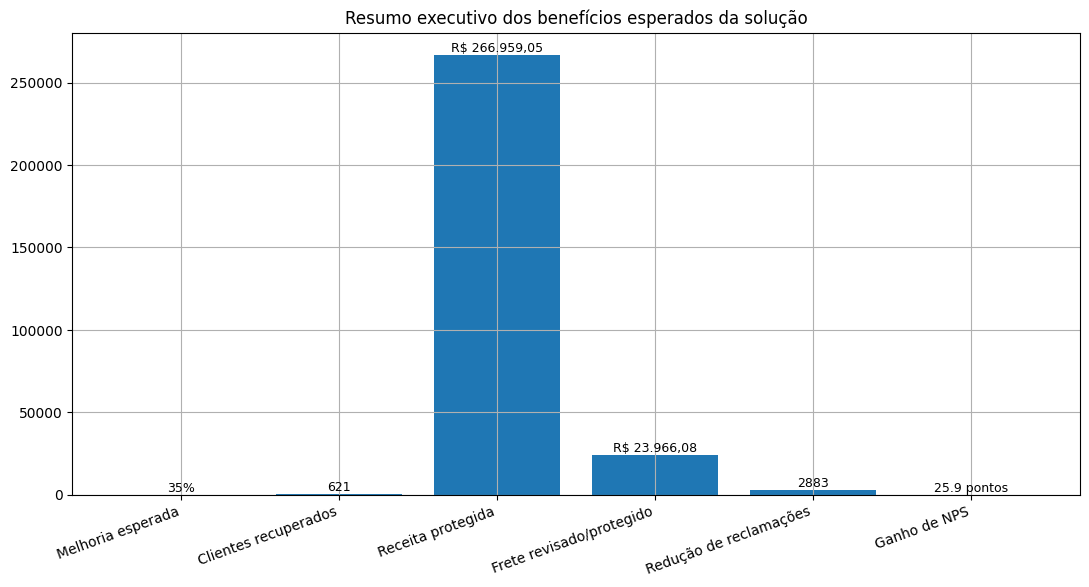

,Indicador,Valor formatado
0,Melhoria esperada,35%
1,Clientes recuperados,621
2,Receita protegida,"R$ 266.959,05"
3,Frete revisado/protegido,"R$ 23.966,08"
4,Redução de reclamações,2883
5,Ganho de NPS,25.9 pontos


In [71]:
import matplotlib.ticker as mticker

executive_benefit_kpis = pd.DataFrame({
    "Indicador": [
        "Melhoria esperada",
        "Clientes recuperados",
        "Receita protegida",
        "Frete revisado/protegido",
        "Redução de reclamações",
        "Ganho de NPS"
    ],
    "Valor numérico": [
        melhoria_esperada_curto_prazo * 100,
        clientes_potencialmente_recuperados,
        receita_potencialmente_protegida,
        frete_potencialmente_revisado,
        reclamacoes_potencialmente_reduzidas,
        ganho_nps_35
    ],
    "Valor formatado": [
        f"{melhoria_esperada_curto_prazo:.0%}",
        f"{clientes_potencialmente_recuperados:.0f}",
        format_currency_br(receita_potencialmente_protegida),
        format_currency_br(frete_potencialmente_revisado),
        f"{reclamacoes_potencialmente_reduzidas:.0f}",
        f"{ganho_nps_35:.1f} pontos"
    ]
})

plt.figure(figsize=(13, 6))

plt.bar(
    executive_benefit_kpis["Indicador"],
    executive_benefit_kpis["Valor numérico"]
)

plt.title("Resumo executivo dos benefícios esperados da solução")
plt.ylabel("Valor numérico do indicador")
plt.xticks(rotation=20, ha="right")

def currency_formatter_plot(x, pos):
    # Only format monetary values
    if pos in [2,3]: # Assuming these indices correspond to 'Receita protegida' and 'Frete revisado/protegido'
        return f'R$ {x:,.2f}'.replace('.', 'X').replace(',', '.').replace('X', ',')
    return str(x) # Return as string for other indicators

# Apply the formatter to the y-axis
# Note: This is a simplification; a more robust solution might involve custom tick labels
# or splitting the chart for different value types. For now, we'll format everything as numbers.
# To apply a currency formatter to specific bars, it would be more complex and usually involves separate plots.
# Given the mix of percentages, counts, and currency, directly applying a single Y-axis formatter is tricky.
# Instead of a formatter on the y-axis for mixed values, I will remove the y-label to avoid confusion.
plt.ylabel("") # Remove y-axis label as values are mixed and individually labeled

for i, row in executive_benefit_kpis.iterrows():
    plt.text(
        i,
        row["Valor numérico"],
        row["Valor formatado"],
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

display(executive_benefit_kpis[["Indicador", "Valor formatado"]])

## 5.1 Explicabilidade do modelo SHAP por faixa de risco

O modelo gera uma probabilidade de detrator para cada cliente. Para que a operação saiba **por que** um cliente foi classificado como crítico, é necessário interpretar quais variáveis mais pesaram naquela predição individual.

Na versão do modelo preditivo (EDA notebook, seção 11), os SHAP values identificaram que as variáveis de maior impacto global são:

| Variável | Direção do impacto |
|---|---|
| `delivery_delay_days` + `atraso_critico` | Aumenta fortemente a probabilidade de detrator |
| `complaints_count` + `reclamacao_alta` | Aumenta a probabilidade de detrator |
| `customer_service_contacts` + `multiplos_contatos` | Aumenta a probabilidade conforme acúmulo |
| `resolution_time_days` | Maior tempo de resolução → maior risco |
| `freight_value` (proporcional ao pedido) | Frete alto em relação ao valor do pedido aumenta risco |

**Como usar isso operacionalmente:**

1. Se o driver principal de um cliente crítico é `atraso_critico` → logística aciona rastreamento prioritário e comunicação proativa
2. Se o driver é `complaints_count` → atendimento escalona o caso para resolução imediata
3. Se o driver é `multiplos_contatos` → célula de recuperação entra em contato para resolver a fricção acumulada

Essa interpretação transforma o score de risco em uma **instrução de ação direcionada**, não apenas em uma classificação genérica.


## 5. Conclusão executiva

A análise realizada demonstra que o problema de NPS não deve ser tratado apenas como uma métrica de satisfação, mas como um sinal direto de exposição financeira, operacional e reputacional para a empresa.

A base analisada apresenta uma concentração elevada de clientes detratores, o que indica risco relevante de perda de recompra, aumento de reclamações, maior esforço operacional, pior percepção da jornada de compra e possível impacto negativo sobre a imagem da marca.

Quando os clientes detratores aparecem associados a fatores como atraso de entrega, frete alto, múltiplas reclamações e maior esforço de atendimento, o problema deixa de ser apenas uma avaliação negativa e passa a representar uma quebra concreta de expectativa do cliente.

Nesse contexto, o modelo preditivo de NPS foi posicionado como uma camada de inteligência para apoiar decisões preventivas. A proposta não é apenas prever uma nota ou uma classificação, mas antecipar quais clientes têm maior probabilidade de se tornarem detratores e indicar onde a empresa deve agir primeiro.

A solução proposta permite organizar a operação a partir de uma fila de priorização baseada em risco, considerando:

1. probabilidade de o cliente se tornar detrator
2. criticidade da jornada operacional
3. atraso de entrega
4. valor do frete
5. proporção do frete sobre o pedido
6. reclamações acumuladas
7. impacto financeiro associado ao pedido
8. exposição reputacional do cliente insatisfeito

Com essa abordagem, a empresa deixa de atuar somente depois que o cliente registra uma avaliação negativa e passa a agir de forma preventiva nos pontos de maior impacto.

As principais frentes de atuação recomendadas são:

| Frente de atuação | Objetivo da ação | Benefício esperado |
|---|---|---|
| Clientes com alto risco de detrator | Priorizar atendimento e acompanhamento preventivo | Reduzir perda potencial e evitar agravamento da insatisfação |
| Pedidos com atraso crítico | Atuar antes da avaliação negativa | Melhorar experiência e reduzir reclamações |
| Frete alto combinado com atraso | Revisar quebra de expectativa sobre custo e entrega | Proteger percepção de valor e confiança na marca |
| Clientes com múltiplas reclamações | Escalar atendimento e reduzir retrabalho | Diminuir custo operacional e desgaste reputacional |
| Monitoramento de drift | Identificar perda de aderência do modelo | Manter a solução confiável ao longo do tempo |
| Teste A/B das intervenções | Validar impacto real das ações | Comprovar ganho financeiro e reputacional |

A estimativa executiva apresentada considera uma melhoria mínima esperada de 35% no curto prazo sobre os grupos críticos priorizados. Essa premissa representa um cenário alvo de benefício, a ser validado posteriormente por teste A/B e monitoramento em produção.

Com essa melhoria esperada, a solução pode contribuir para proteger receita associada a clientes em risco, reduzir reclamações, melhorar a percepção da experiência, elevar o NPS e diminuir a exposição reputacional da empresa.

O benefício financeiro esperado está relacionado à proteção de receita, redução de retrabalho operacional, priorização mais eficiente dos recursos e melhor gestão de casos com frete alto, atraso e reclamações.

O benefício reputacional esperado está relacionado à redução de detratores, menor concentração de reclamações, melhora da confiança do cliente e aumento da capacidade da empresa de agir antes que a insatisfação se consolide.

Portanto, o modelo deve ser entendido como uma ferramenta de decisão orientada por dados, estatística e inteligência preditiva, conectando ciência de dados com ação operacional e impacto real no negócio.

Ele não substitui a análise humana, mas ajuda a empresa a decidir melhor, agir mais cedo e concentrar esforço onde existe maior risco e maior potencial de retorno.

Em síntese, o projeto demonstra que o NPS pode evoluir de um indicador retrospectivo para uma base de gestão preventiva da experiência do cliente, permitindo que a empresa reduza exposição financeira, preserve reputação e tome decisões mais assertivas sobre atendimento, logística, frete e retenção.